(mmm_funnel_mueffect_advanced)=
# Advanced Funnel-Aware MMM: Geo-Level Mediation Through Lower-Funnel Spend

The {ref}`mmm_funnel_mueffect` notebook introduced the core idea: upper-funnel
activity creates demand that shows up later in lower-funnel channels, and we can
encode that mediation directly in `pymc-marketing` through a custom
{class}`~pymc_marketing.mmm.additive_effect.MuEffect` carrying its own likelihood.
That example kept the funnel deliberately minimal -- one upper channel, one
mediator, one national time series.

Real engagements are not that tidy. This notebook scales the same idea up to a
setup that looks much more like production work:

1. **Several upper-funnel channels** feed the same latent demand pool, each with
   its own carryover and saturation.
2. **A geo panel**: the model is fit across regions at once, with some parameters
   pooled across geos and others estimated per geo.
3. **A mediator that is itself media.** Lower-funnel spend is not a passive
   symptom of demand -- it is paid search, and it converts. It sits *on* the causal
   path, driven partly by the demand that upper-funnel activity creates and partly
   by an exogenous budget of its own.
4. **A second, purely observational proxy.** Branded search volume measures the
   same latent demand but causes nothing. Keeping a *cause* and an *indicator*
   distinct is most of the modeling problem.
5. **Seasonal confounding**: category demand is seasonal, media plans follow that
   seasonality, and the target has its own seasonality on top.

Along the way we use two pieces of the library that make this much less painful
than hand-rolling everything:

- {class}`~pymc_marketing.mmm.additive_effect.DataVarMuEffect`, which reads the
  effect's data straight out of the training `xarray` dataset, so we only write
  the part of the effect that is genuinely custom.
- `pymc.dims` **xtensors**, whose named broadcasting lets a `("geo",)` parameter,
  a `("channel",)` parameter and a `("date", "geo", "channel")` data array combine
  without a single `reshape` or `None`-index.

```{note}
This is a self-contained methodological example built on fully synthetic data. It
does not reference any specific client or engagement.
```

## The funnel structure

We model a weekly geo panel. Within every geo $g$ and week $t$:

- `tv_spend`, `social_spend` ($U_{t,g,c}$): two **upper-funnel** channels.
- `category_demand` ($C_{t,g}$): an exogenous, seasonal index of how much the
  whole category is in-market (think a category-level search-trend index). It
  drives lower-funnel demand but does **not** act on the target directly -- an
  **exclusion restriction** on the mediator equation.
- `lf_budget` ($B_{t,g}$): an exogenous lower-funnel budget -- always-on spend plus
  promotional pushes, set by the search team on its own calendar rather than in
  response to demand.
- $D_{t,g}$: **latent demand**. Never observed.
- $M^{*}_{t,g}$: **structural lower-funnel spend**, the quantity that actually buys
  conversions. `lower_spend` is this observed with reporting noise.
- `search_volume` ($S_{t,g}$): branded search volume, an **indicator** of $D$.
- `y` ($Y_{t,g}$): the target.

Upper-funnel activity and the category cycle create demand:

$$
D_{t,g} = \text{baseline}_g + \gamma_g\, C_{t,g}
          + \sum_{c} \text{sat}^{uf}\!\left(\text{adstock}^{uf}(U_{t,g,c})\right).
$$

That demand is one of two things the search team's spend responds to; the other is
its own budget. Both parts are real money and both convert:

$$
M^{*}_{t,g} = D_{t,g} + \lambda_g B_{t,g},
\qquad
\texttt{lower\_spend}_{t,g} \sim
  \text{TruncatedNormal}(M^{*}_{t,g},\, \sigma^M_g,\, \text{lower}=0).
$$

Branded search, by contrast, buys nothing. It is a **pure indicator** -- people
search for the brand *because* they are in-market:

$$
S_{t,g} \sim \text{Normal}(\kappa\, D_{t,g},\, \sigma^S_g).
$$

Finally the target responds to lower-funnel spend, plus the direct effect of each
upper channel and its own seasonality:

$$
Y_{t,g} = \text{intercept}_g
        + \sum_c \text{sat}\!\left(\text{adstock}(U_{t,g,c})\right)
        + \text{Fourier}(t)\cdot\gamma^{F}_g
        + \text{sat}^{lf}\!\left(\text{adstock}^{lf}(M^{*}_{t,g})\right)
        + \varepsilon_{t,g}.
$$

Every upper channel therefore reaches the target along **two paths**: directly, and
indirectly along $U \to D \to M^{*} \to Y$.

### Why only one of the two downstream variables points at the target

This asymmetry is the heart of the example, so it is worth stating bluntly.

**Lower-funnel spend belongs in the target equation.** It is paid media. Money goes
in, conversions come out, and a model that leaves it out is missing a real driver.
What makes it a *mediator* rather than an ordinary channel is that its level is not
chosen freely: part of it is a response to demand that upper-funnel activity
created. Credit for that part belongs upstream.

**Branded search volume does not.** Nobody buys search volume; it is a symptom of
being in-market. Drawing $S \to Y$ would invent a causal channel that does not
exist, and -- as `Naive C` below demonstrates -- putting it into an MMM as if it
were a channel silently blocks the very path we are trying to measure.

The practical test is not "is this variable predictive of sales?" Both are, very.
It is "if I doubled it, would sales move?" That question separates a spend line
from a tracking metric, and no amount of model fit will answer it for you.

```{note}
**What anchors the latent scale.** $D$ is latent, so something has to fix its
units. Here it is the coefficient on $D$ in the $M^{*}$ equation, which is pinned
at exactly one: latent demand is measured *in units of the lower-funnel spend it
induces*. Everything else is then relative to that -- $\kappa$ is free, and
$\lambda$ converts budget into the same units. Were that coefficient free too,
rescaling $D$ and compensating in $\kappa$ would leave the likelihood untouched.
```

Two further structural features make this harder than the single-channel case.

**Seasonal confounding.** Category demand is seasonal, and media plans are built
around that same seasonality, so upper-funnel spend and category demand move
together. Season is thus a common cause of the mediator and (through its own
Fourier terms) of the target. A model that omits the mediator has to attribute
seasonal demand somewhere, and it will hand it to whichever channel co-moves with
it most.

**A shared, saturating demand pool.** Because both channels push on the *same*
saturating function, their indirect effects are not additive. Turning off TV alone
and turning off social alone remove *less* demand between them than turning off
both at once -- each channel is partly shielded by the other's contribution
sitting further along the concave curve. We quantify this below.

Identification rests on **two exclusion restrictions**, and it is worth naming them
because between them they are what make the funnel estimable at all. Category
demand $C$ enters the demand equation but not the target. The lower-funnel budget
$B$ enters the spend equation but not the search equation -- which is precisely
what lets the model tell $\lambda B$ apart from $D$ rather than lumping the two
into one unidentified level.

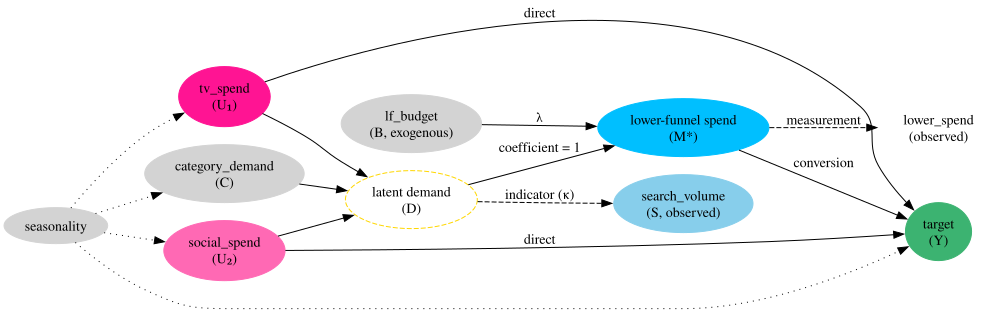

In [1]:
import graphviz as gr

g = gr.Digraph()
g.attr(rankdir="LR")
g.attr("node", shape="ellipse")

g.node("S1", "seasonality", color="lightgray", style="filled")
g.node("U1", "tv_spend\n(U₁)", color="deeppink", style="filled")
g.node("U2", "social_spend\n(U₂)", color="hotpink", style="filled")
g.node("C", "category_demand\n(C)", color="lightgray", style="filled")
g.node("B", "lf_budget\n(B, exogenous)", color="lightgray", style="filled")
g.node("D", "latent demand\n(D)", color="gold", style="dashed")
g.node("MS", "lower-funnel spend\n(M*)", color="deepskyblue", style="filled")
g.node("M", "lower_spend\n(observed)", color="white", style="dashed")
g.node("SV", "search_volume\n(S, observed)", color="skyblue", style="filled")
g.node("Y", "target\n(Y)", color="mediumseagreen", style="filled")

g.edge("S1", "U1", style="dotted")
g.edge("S1", "U2", style="dotted")
g.edge("S1", "C", style="dotted")
g.edge("S1", "Y", style="dotted")
g.edge("U1", "Y", label="direct")
g.edge("U2", "Y", label="direct")
g.edge("U1", "D")
g.edge("U2", "D")
g.edge("C", "D")
g.edge("D", "MS", label="coefficient = 1")
g.edge("B", "MS", label="λ")
g.edge("MS", "M", label="measurement", style="dashed")
g.edge("D", "SV", label="indicator (κ)", style="dashed")
g.edge("MS", "Y", label="conversion")

g

The whole graph is replicated across geos. Which parameters are shared and which
are free per geo is a modeling choice, and with roughly 130 weeks per geo it is a
consequential one:

| Parameter | Dimensions | Why |
|---|---|---|
| `adstock_alpha`, `adstock_uf_alpha`, `saturation_lam`, `sat_uf_lam` | `("channel",)` | Carryover and curvature are properties of the medium, not the region; pooling them buys a lot of precision. |
| `saturation_beta`, `sat_uf_beta` | `("geo", "channel")` | Response *amplitude* genuinely differs by region (market size, competition). |
| `intercept`, `funnel_baseline`, `funnel_gamma`, `funnel_lambda`, the noise scales | `("geo",)` | Regional levels and volatility; how strongly budget converts into spend is a regional operating choice. |
| `funnel_kappa` | scalar | The search index is the same instrument everywhere, so its loading is shared. |

Mixing pooled and unpooled parameters in one expression is where xtensors earn
their keep: `pymc.dims` aligns operands **by dimension name**, so a
`("channel",)` decay multiplies a `("date", "geo", "channel")` media array with no
manual broadcasting.

## Prepare Notebook

In [2]:
import arviz as az
import arviz_plots as azp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pymc.dims as pmd
import pytensor.tensor as pt
import xarray as xr
from pydantic import InstanceOf
from pymc import do
from pymc_extras.prior import Prior

from pymc_marketing.mmm import GeometricAdstock, LogisticSaturation
from pymc_marketing.mmm.additive_effect import DataVarMuEffect
from pymc_marketing.mmm.media_transformation import MediaTransformation
from pymc_marketing.mmm.mmm import MMM

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [3]:
seed: int = sum(map(ord, "advanced funnel"))
rng: np.random.Generator = np.random.default_rng(seed=seed)


def hdi_bounds(da, prob: float = 0.94):
    """Return (lower, upper) HDI DataArrays for a posterior DataArray."""
    h = az.hdi(da, prob=prob)
    if isinstance(h, xr.Dataset):
        h = h[next(iter(h.data_vars))]
    return h.sel(ci_bound="lower"), h.sel(ci_bound="upper")


FOREST_COLORS = ["C2", "C4", "C5", "C3", "C0"]


def forest_panel(ax, rows, reference=None, annotate=True):
    """Draw one mean-and-HDI interval per row, with optional reference lines.

    ``rows`` maps a label to a posterior ``DataArray``. ``reference`` maps a label
    to ``(value, style)`` and is drawn as a full-height vertical line; the first
    entry is the benchmark the bias annotations are measured against, unless a row
    label ends in ``(direct only)``.
    """
    labels = list(rows)
    for i, label in enumerate(labels):
        draws = rows[label]
        lo, hi = hdi_bounds(draws)
        mean = float(draws.mean())
        color = FOREST_COLORS[i % len(FOREST_COLORS)]
        ax.plot([float(lo), float(hi)], [i, i], color=color, lw=3.5, alpha=0.65)
        ax.plot([mean], [i], "o", color=color, ms=9)
        if annotate and reference:
            key = "direct" if label.endswith("(direct only)") else next(iter(reference))
            benchmark = reference.get(key, next(iter(reference.values())))[0]
            ax.annotate(
                f"{mean / benchmark - 1:+.0%}",
                (mean, i),
                textcoords="offset points",
                xytext=(0, -15),
                ha="center",
                va="top",
                fontsize=9,
                bbox={
                    "boxstyle": "round,pad=0.15",
                    "fc": "white",
                    "ec": "none",
                    "alpha": 0.75,
                },
            )
    for name, (value, style) in (reference or {}).items():
        ax.axvline(value, label=f"true {name}", **style)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_ylim(-0.7, len(labels) - 0.3)
    ax.invert_yaxis()


TRUE_STYLE = {
    "total": {"color": "black", "linestyle": "--", "linewidth": 2},
    "direct": {"color": "gray", "linestyle": ":", "linewidth": 2},
}

## Configuration

In [4]:
n_dates = 130
l_max = 8
geos = ["north", "south", "west"]
channels = ["tv_spend", "social_spend"]

date_range = pd.date_range(start="2021-01-04", freq="W-MON", periods=n_dates)
coords = {"date": date_range, "geo": geos}

## The `FunnelEffect` component

A {class}`~pymc_marketing.mmm.additive_effect.MuEffect` adds an arbitrary term to
the target mean through a three-method protocol: `create_data` registers the data
the effect needs, `create_effect` builds and returns the term, and `set_data`
refreshes the data at prediction time. Because `create_effect` runs *inside* the
model context, it can declare **its own observed likelihoods** -- which is what
turns "add a term to `mu`" into "fit extra structural equations jointly".

{class}`~pymc_marketing.mmm.additive_effect.DataVarMuEffect` removes most of that
boilerplate. It takes a list of `data_vars` naming variables in the training
dataset and implements `create_data` and `set_data` for us, registering each one
with the dimensions it already carries in the dataset. Compared with the
hand-written effect in {ref}`mmm_funnel_mueffect`, this deletes the data-carrying
fields, `create_data`, and `set_data` -- and it fixes a subtle limitation of the
hand-rolled version, whose `set_data` ignored the prediction frame entirely.

The `MediaTransformation` helper does the same for the adstock/saturation pairs:
instead of four loose components, we hold two transformation objects and let each
manage its own ordering and prior dimensions.

What remains in `create_effect` is exactly the part that *is* the funnel:

In [5]:
class FunnelEffect(DataVarMuEffect):
    """Geo-level upper-funnel mediation through lower-funnel spend.

    Encodes ``upper channels -> latent demand -> lower-funnel spend -> target`` as
    an additive effect on the target mean, while jointly fitting the observed
    lower-funnel spend and an indicator of the latent demand.
    """

    upper_transform: InstanceOf[MediaTransformation]
    demand_transform: InstanceOf[MediaTransformation]

    model_config = {"arbitrary_types_allowed": True}

    def to_dict(self) -> dict:
        """Serialize the effect (transformations delegate to their own dicts)."""
        return {
            "data_vars": self.data_vars,
            "prefix": self.prefix,
            "upper_transform": self.upper_transform.to_dict(),
            "demand_transform": self.demand_transform.to_dict(),
        }

    def create_effect(self, mmm):
        """Build the mediator equation, its likelihoods, and the target effect."""
        model = mmm.model

        # ("date", "geo", "channel") -> ("date", "geo"): every upper channel
        # pushes on the same demand pool, so we sum the channel dimension away.
        upper_on_demand = self.upper_transform(mmm.channel_data_scaled, dim="date").sum(
            dim="channel"
        )

        # Structural equation 1: upper spend + category demand -> latent demand.
        baseline = pmd.HalfNormal(f"{self.prefix}_baseline", sigma=1.0, dims=("geo",))
        gamma = pmd.HalfNormal(f"{self.prefix}_gamma", sigma=1.0, dims=("geo",))
        demand = pmd.Deterministic(
            f"{self.prefix}_demand",
            baseline + gamma * model["category_demand"] + upper_on_demand,
        )

        # Structural equation 2: lower-funnel spend responds to demand (coefficient
        # fixed at 1, which anchors D's scale) and to its own exogenous budget.
        lam_b = pmd.HalfNormal(f"{self.prefix}_lambda", sigma=0.5, dims=("geo",))
        lf_spend = pmd.Deterministic(
            f"{self.prefix}_lf_spend",
            demand + lam_b * model["lf_budget"],
        )

        # Observation: reported lower-funnel spend, up to reporting noise.
        pmd.TruncatedNormal(
            f"{self.prefix}_lower_spend_likelihood",
            mu=lf_spend,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma_m", sigma=1.0, dims=("geo",)),
            lower=0.0,
            observed=model["lower_spend"],
        )

        # Indicator: branded search volume loads on demand, not on spend.
        kappa = pmd.HalfNormal(f"{self.prefix}_kappa", sigma=1.0)
        pmd.Normal(
            f"{self.prefix}_search_likelihood",
            mu=kappa * demand,
            sigma=pmd.HalfNormal(f"{self.prefix}_sigma_s", sigma=1.0, dims=("geo",)),
            observed=model["search_volume"],
        )

        # Structural equation 3: lower-funnel spend -> target contribution.
        return pmd.Deterministic(
            f"{self.prefix}_effect_contribution",
            self.demand_transform(lf_spend, dim="date"),
        )

The factory below wires up the two transformations and, crucially, sets the
**dimensions of each prior** according to the pooling table above. `GeometricAdstock`
and `LogisticSaturation` accept a `priors` dictionary, so `alpha` and `lam` get
`dims="channel"` (pooled across geos) while `beta` gets `dims=("geo", "channel")`.
Unique `prefix` values keep these parameters from colliding with the base `MMM`'s
own direct-path transforms.

In [6]:
def make_funnel_effect() -> FunnelEffect:
    """Construct the funnel effect with uniquely-prefixed transformations."""
    return FunnelEffect(
        data_vars=["lower_spend", "search_volume", "category_demand", "lf_budget"],
        prefix="funnel",
        upper_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max,
                prefix="adstock_uf",
                priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="channel")},
            ),
            saturation=LogisticSaturation(
                prefix="sat_uf",
                priors={
                    "lam": Prior("Gamma", mu=2.0, sigma=1.0, dims="channel"),
                    "beta": Prior("HalfNormal", sigma=1.0, dims=("geo", "channel")),
                },
            ),
            adstock_first=True,
            dims=("geo", "channel"),
        ),
        demand_transform=MediaTransformation(
            adstock=GeometricAdstock(
                l_max=l_max,
                prefix="adstock_lf",
                priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="geo")},
            ),
            saturation=LogisticSaturation(
                prefix="sat_lf",
                priors={
                    "lam": Prior("Gamma", mu=1.5, sigma=0.5),
                    "beta": Prior("HalfNormal", sigma=1.0, dims="geo"),
                },
            ),
            adstock_first=True,
            dims=("geo",),
        ),
    )

### A note on data plumbing

`DataVarMuEffect` looks its variables up in `mmm.xarray_dataset`, the dataset the
`MMM` stores when the model is built. That has a practical consequence worth
stating plainly, because it is easy to trip over:

> **A `pandas.DataFrame` will silently drop your funnel columns.** When `X` is a
> DataFrame, the conversion keeps only the channel and control columns; anything
> else disappears. To make extra variables visible to the effect, build the model
> from an `xarray.Dataset`, where every data variable survives.

There is a second wrinkle. `MMM.fit` records a `fit_data` group by converting `X`
back to a flat frame, and that bookkeeping step does not currently handle a
`Dataset` whose media variable carries a `channel` dimension. So we **build** with
the `Dataset` (which is what populates the model) and **fit** with the equivalent
long DataFrame (which is only used for bookkeeping, since `fit` does not rebuild
an already-built model). The model itself is entirely determined by the `Dataset`.

## Data generating process

As in {ref}`mmm_data_generator`, we build a model, clamp every parameter to a
known value with the
[`do`](https://www.pymc.io/projects/docs/en/stable/api/model/generated/pymc.model.transform.conditioning.do.html)
operator, and forward-sample. The generative model **is** the funnel MMM, so one
forward pass produces the target and both demand proxies at once.

### Exogenous covariates

Three of the drivers -- two media plans and the category demand index -- share a
common annual seasonal component, which is precisely the confounding we want. Each
has its own level, trend and seasonal amplitude; correlated noise comes from an
LKJ prior, and a `softplus` keeps everything non-negative. Regions are then scaled
by a size multiplier.

In [7]:
t = np.arange(n_dates) / n_dates
week_of_year = date_range.isocalendar().week.to_numpy() / 52.0
season = np.sin(2 * np.pi * week_of_year)

drivers = ["tv_spend", "social_spend", "category_demand"]
geo_size = np.array([1.0, 0.7, 0.45])

level = np.array([0.10, 0.05, 0.30])
trend = np.array([0.30, 0.25, 0.10])
seasonal_amplitude = np.array([0.80, 0.40, 0.70])

cov_coords = {"date": date_range, "geo": geos, "driver": drivers}
with pm.Model(coords=cov_coords) as covariates_model:
    L, _, _ = pm.LKJCholeskyCov("L", n=3, eta=50, sd_dist=pm.Exponential.dist(lam=4.0))
    mu_cov = (
        level + trend * t[:, None, None] + seasonal_amplitude * season[:, None, None]
    )
    x_raw = pm.MvNormal("x_raw", mu=mu_cov, chol=L, dims=("date", "geo", "driver"))
    x = pm.Deterministic("x", pt.softplus(x_raw), dims=("date", "geo", "driver"))

In [8]:
x_data = pm.draw(covariates_model.x, draws=1, random_seed=rng) * geo_size[None, :, None]

media_raw = x_data[..., :2]
category_demand = x_data[..., 2] / x_data[..., 2].max()

The lower-funnel budget is generated differently on purpose. It is **not**
seasonal and it does not follow the media plans: a low always-on level with
occasional promotional pushes on the search team's own calendar. That shape is
what makes it useful -- the pushes are exogenous shocks to lower-funnel spend, and
they are what let the model separate the budget-driven part of that spend from the
demand-driven part.

In [9]:
promo = rng.binomial(n=1, p=0.35, size=(n_dates, len(geos)))
magnitude = rng.gamma(shape=2.0, scale=0.30, size=(n_dates, len(geos)))
lf_budget = geo_size[None, :] * (0.12 + promo * magnitude)

for gi, geo in enumerate(geos):
    b = lf_budget[:, gi]
    print(
        f"{geo:6s} lf_budget mean {b.mean():.3f}  sd {b.std():.3f}  sd/mean {b.std() / b.mean():.2f}"
    )

north  lf_budget mean 0.314  sd 0.358  sd/mean 1.14
south  lf_budget mean 0.234  sd 0.275  sd/mean 1.17
west   lf_budget mean 0.166  sd 0.198  sd/mean 1.19


The variation matters: a budget that sat flat at its always-on level would carry no
information, and $\lambda$ would be absorbed into the demand baseline. Here the
standard deviation slightly exceeds the mean.

The other thing to check is that the budget really is exogenous. A promotional
calendar that happened to follow the category cycle would be a second confounder
rather than a source of clean variation:

In [10]:
driver_names = ["tv_spend", "social_spend", "category_demand", "lf_budget"]
corr_frames = {}
for gi, geo in enumerate(geos):
    stacked = np.column_stack(
        [
            media_raw[:, gi, 0],
            media_raw[:, gi, 1],
            category_demand[:, gi],
            lf_budget[:, gi],
        ]
    )
    corr_frames[geo] = pd.DataFrame(
        np.corrcoef(stacked, rowvar=False), index=driver_names, columns=driver_names
    )

corr_table = pd.concat(corr_frames, names=["geo", "driver"])
print(
    "max |corr| involving lf_budget: "
    f"{corr_table['lf_budget'].drop(index='lf_budget', level='driver').abs().max():.3f}"
)
corr_table.style.background_gradient(cmap="RdBu_r", vmin=-1, vmax=1).format("{:+.2f}")

max |corr| involving lf_budget: 0.108


`lf_budget` is essentially uncorrelated with everything else (all well under 0.15),
while **social spend tracks category demand much more closely than TV does**. Keep
that second fact in mind -- it will decide *where* the bias lands in the naive
models.

### Ground-truth parameters

Every structural parameter gets an explicit true value, with the shape implied by
its dimensions. Rather than trusting our memory of which parameter is pooled, we
build the model first and read the dimensions off it.

In [11]:
true = {
    # target equation: direct paths and seasonality
    "intercept_contribution": np.array([0.35, 0.28, 0.22]),
    "adstock_alpha": np.array([0.55, 0.30]),
    "saturation_lam": np.array([3.0, 4.0]),
    "saturation_beta": np.array([[0.55, 0.35], [0.45, 0.30], [0.35, 0.25]]),
    "gamma_fourier": np.array(
        [
            [0.05, 0.03, 0.02, -0.02],
            [0.04, 0.02, 0.02, -0.01],
            [0.03, 0.02, 0.01, -0.01],
        ]
    ),
    "y_sigma": np.array([0.04, 0.04, 0.04]),
    # mediator equation: upper spend + category demand -> latent demand
    "funnel_baseline": np.array([0.20, 0.16, 0.12]),
    "funnel_gamma": np.array([0.35, 0.30, 0.25]),
    "adstock_uf_alpha": np.array([0.60, 0.35]),
    "sat_uf_lam": np.array([2.5, 3.0]),
    "sat_uf_beta": np.array([[0.85, 0.55], [0.70, 0.45], [0.55, 0.35]]),
    # lower-funnel spend equation and its observation
    "funnel_lambda": np.array([0.50, 0.45, 0.40]),
    "funnel_sigma_m": np.array([0.05, 0.05, 0.05]),
    # branded-search indicator
    "funnel_kappa": np.array(0.8),
    "funnel_sigma_s": np.array([0.05, 0.05, 0.05]),
    # conversion path: lower-funnel spend -> target
    "adstock_lf_alpha": np.array([0.35, 0.30, 0.25]),
    "sat_lf_lam": np.array(1.5),
    "sat_lf_beta": np.array([1.05, 0.90, 0.72]),
}

### Model configuration

The same priors are used for the generative model and for the models we fit, so we
define them once. Note the `scaling` block: `dims=()` means "take the maximum over
the date dimension only", giving one scale per geo (and per channel), which is the
usual choice for a geo panel where regions differ in size.

In [12]:
SCALING = {
    "channel": {"method": "max", "dims": ()},
    "target": {"method": "max", "dims": ()},
}

MODEL_CONFIG = {
    "intercept": Prior("Normal", mu=0.2, sigma=0.2, dims="geo"),
    "gamma_fourier": Prior("Normal", mu=0, sigma=0.1, dims=("geo", "fourier_mode")),
    "likelihood": Prior(
        "Normal",
        sigma=Prior("HalfNormal", sigma=0.5, dims="geo"),
        dims=("date", "geo"),
    ),
}


def make_mmm(channel_columns: list[str], **kwargs) -> MMM:
    """Build the base MMM shared by the generative and fitted models."""
    return MMM(
        date_column="date",
        target_column="y",
        channel_columns=channel_columns,
        dims=("geo",),
        scaling=SCALING,
        adstock=GeometricAdstock(
            l_max=l_max,
            priors={"alpha": Prior("Beta", alpha=2, beta=3, dims="channel")},
        ),
        saturation=LogisticSaturation(
            priors={
                "lam": Prior("Gamma", mu=3.0, sigma=1.0, dims="channel"),
                "beta": Prior("HalfNormal", sigma=1.0, dims=("geo", "channel")),
            }
        ),
        yearly_seasonality=2,
        model_config=MODEL_CONFIG,
        **kwargs,
    )


def make_dataset(media, lower_spend, search_volume, cat_demand, budget) -> xr.Dataset:
    """Assemble the xarray Dataset the funnel model is built from.

    The media variable must be named ``media`` (not ``channel``, which xarray would
    promote to a coordinate) and carry a ``channel`` dimension. Every variable named
    in the effect's ``data_vars`` must appear here, or ``build_model`` raises.
    """
    return xr.Dataset(
        {
            "media": xr.DataArray(media, dims=("date", "geo", "channel")),
            "lower_spend": xr.DataArray(lower_spend, dims=("date", "geo")),
            "search_volume": xr.DataArray(search_volume, dims=("date", "geo")),
            "category_demand": xr.DataArray(cat_demand, dims=("date", "geo")),
            "lf_budget": xr.DataArray(budget, dims=("date", "geo")),
        },
        coords={**coords, "channel": channels},
    )

### Forward simulation

We build the generative model on dummy observations and a dummy target (all ones,
so the target scale is one and the true parameters are on the natural scale), then
clamp and sample.

```{warning}
`lower_spend` and `search_volume` are placeholders here -- they are *outputs* of
the forward pass. `lf_budget` is **not**: it is a genuine input to the mediator
equation and must be the real series. Passing ones for it would leave $\lambda$
multiplying a constant, and the failure would be silent -- sampling still succeeds,
and $\lambda$'s posterior simply reverts to its prior.
```

In [13]:
ones = np.ones((n_dates, len(geos)))
ds_gen = make_dataset(media_raw, ones, ones, category_demand, lf_budget)
y_gen = xr.DataArray(ones, dims=("date", "geo"), coords=coords)

gen = make_mmm(channels)
gen.add_mu_effect(make_funnel_effect())
gen.build_model(X=ds_gen, y=y_gen)
gen.add_original_scale_contribution_variable(
    var=["channel_contribution", "funnel_effect_contribution", "y"]
)

pd.DataFrame(
    [(v, gen.model.named_vars_to_dims.get(v), true[v].shape) for v in true],
    columns=["parameter", "dims", "true value shape"],
)

,parameter,dims,true value shape
0,intercept_contribution,"(geo,)","(3,)"
1,adstock_alpha,"(channel,)","(2,)"
2,saturation_lam,"(channel,)","(2,)"
3,saturation_beta,"(geo, channel)","(3, 2)"
4,gamma_fourier,"(geo, fourier_mode)","(3, 4)"
5,y_sigma,"(geo,)","(3,)"
6,funnel_baseline,"(geo,)","(3,)"
7,funnel_gamma,"(geo,)","(3,)"
8,adstock_uf_alpha,"(channel,)","(2,)"
9,sat_uf_lam,"(channel,)","(2,)"


Reading the dimensions off the model before writing the intervention is a habit
worth keeping: `do` requires the clamped values to match the model's shapes
exactly, and the pooling choices above mean those shapes are not all obvious.

The model graph makes the **three** likelihoods explicit -- the target and the two
demand proxies are all children of the same set of latent parameters.

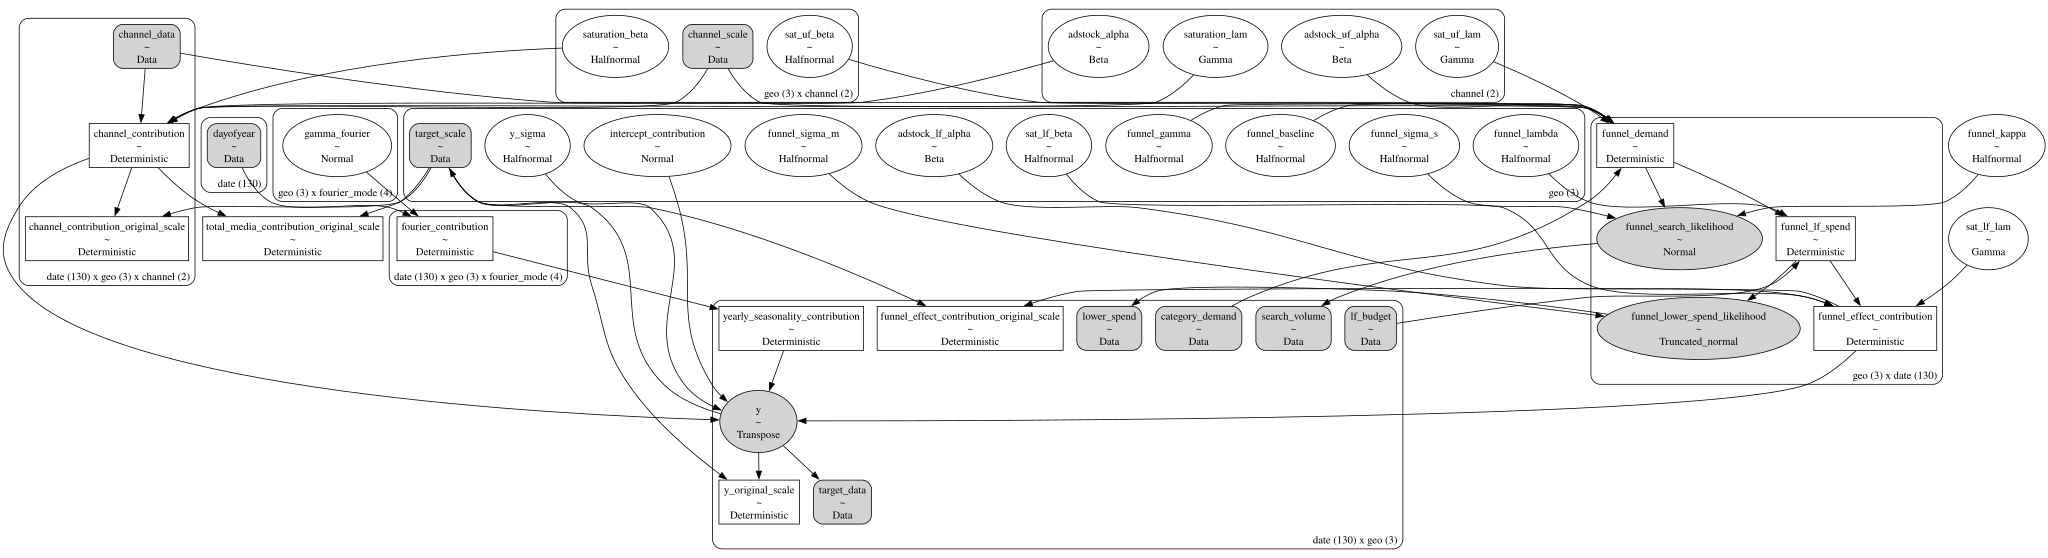

In [14]:
pm.model_to_graphviz(gen.model)

In [15]:
gen.model = do(gen.model, true)

var_names = [
    "y_original_scale",
    "channel_contribution_original_scale",
    "funnel_effect_contribution_original_scale",
    "funnel_demand",
    "funnel_lf_spend",
]
pp_names = ["funnel_lower_spend_likelihood", "funnel_search_likelihood"]

with gen.model:
    idata_gen = pm.sample_prior_predictive(
        draws=1, var_names=var_names + pp_names, random_seed=rng
    )

prior = idata_gen["prior"].sel(chain=0, draw=0)
prior_pp = idata_gen["prior_predictive"].sel(chain=0, draw=0)

y_obs = prior["y_original_scale"].transpose("date", "geo").to_numpy()
demand_true = prior["funnel_demand"].transpose("date", "geo").to_numpy()
lf_spend_true = prior["funnel_lf_spend"].transpose("date", "geo").to_numpy()
lower_spend_obs = (
    prior_pp["funnel_lower_spend_likelihood"].transpose("date", "geo").to_numpy()
)
search_obs = prior_pp["funnel_search_likelihood"].transpose("date", "geo").to_numpy()
direct_true = (
    prior["channel_contribution_original_scale"]
    .transpose("date", "geo", "channel")
    .to_numpy()
)
indirect_raw = (
    prior["funnel_effect_contribution_original_scale"]
    .transpose("date", "geo")
    .to_numpy()
)

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_lower_spend_likelihood, funnel_search_likelihood, y]


### The true causal decomposition

The raw `funnel_effect_contribution` includes the demand that comes from the
baseline and the category index, which upper-funnel spend never created. To
isolate each channel's **causal** indirect contribution we re-run the clamped
generative model with that channel's spend set to zero and subtract. Running the
same counterfactual with *both* channels off lets us measure the non-additivity.

In [16]:
def forward_with_zeroed(channel_mask) -> np.ndarray:
    """Mediated contribution when the masked channels are set to zero spend."""
    media_cf = media_raw.copy()
    media_cf[..., channel_mask] = 0.0
    with gen.model:
        pm.set_data({"channel_data": media_cf})
        idata_cf = pm.sample_prior_predictive(
            draws=1,
            var_names=["funnel_effect_contribution_original_scale"],
            random_seed=rng,
        )
    return (
        idata_cf["prior"]
        .sel(chain=0, draw=0)["funnel_effect_contribution_original_scale"]
        .transpose("date", "geo")
        .to_numpy()
    )


indirect_true = np.stack(
    [
        indirect_raw - forward_with_zeroed(np.array([True, False])),
        indirect_raw - forward_with_zeroed(np.array([False, True])),
    ],
    axis=-1,
)
indirect_both = indirect_raw - forward_with_zeroed(np.array([True, True]))

# Restore the generative model's media data.
with gen.model:
    pm.set_data({"channel_data": media_raw})

total_true = direct_true + indirect_true

Sampling: []


Sampling: []


Sampling: []


```{note}
Unlike the single-channel example, we keep the **full** date range rather than
dropping the first `l_max` weeks. The generative model and the fitted models apply
the same zero-padded adstock, so the early weeks are not an artifact. Dropping them
would actually *introduce* one: the fitted model would be asked to explain weeks
whose carryover history had been deleted.
```

In [17]:
data = xr.Dataset(
    {
        "tv_spend": (("date", "geo"), media_raw[..., 0]),
        "social_spend": (("date", "geo"), media_raw[..., 1]),
        "category_demand": (("date", "geo"), category_demand),
        "lf_budget": (("date", "geo"), lf_budget),
        "lower_spend": (("date", "geo"), lower_spend_obs),
        "search_volume": (("date", "geo"), search_obs),
        "y": (("date", "geo"), y_obs),
        "demand_true": (("date", "geo"), demand_true),
        "lf_spend_true": (("date", "geo"), lf_spend_true),
        "direct_true": (("date", "geo", "channel"), direct_true),
        "indirect_true": (("date", "geo", "channel"), indirect_true),
        "total_true": (("date", "geo", "channel"), total_true),
    },
    coords={**coords, "channel": channels},
)

shares = (
    data["indirect_true"].mean("date") / data["total_true"].mean("date")
).to_dataframe(name="indirect share")
shares["indirect share"] = shares["indirect share"].map("{:.1%}".format)
shares

indirect share
geo   channel                    
north tv_spend              34.9%
      social_spend          36.9%
south tv_spend              37.5%
      social_spend          37.7%
west  tv_spend              36.9%
      social_spend          34.7%

Between a third and two fifths of every upper-funnel channel's effect travels
through the mediator. Now the non-additivity:

In [18]:
sum_of_singles = float(data["indirect_true"].sum("channel").mean())
joint = float(indirect_both.mean())
print(f"Sum of single-channel indirect effects: {sum_of_singles:.3f}")
print(f"Indirect effect of switching both off:  {joint:.3f}")
print(f"Shortfall from treating paths as additive: {1 - sum_of_singles / joint:.1%}")

Sum of single-channel indirect effects: 0.240
Indirect effect of switching both off:  0.268
Shortfall from treating paths as additive: 10.7%


Because the two channels share one saturating demand pool, per-channel indirect
effects computed one at a time **understate** their joint effect by around 10%.
This is not a bug: with a concave response there is no unique way to split a joint
effect into per-channel pieces, and leave-one-out attribution is one convention
among several. It is worth stating explicitly whenever these numbers inform a
budget conversation.

### Exploratory visualization

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_79659/725611597.py:29: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.98))


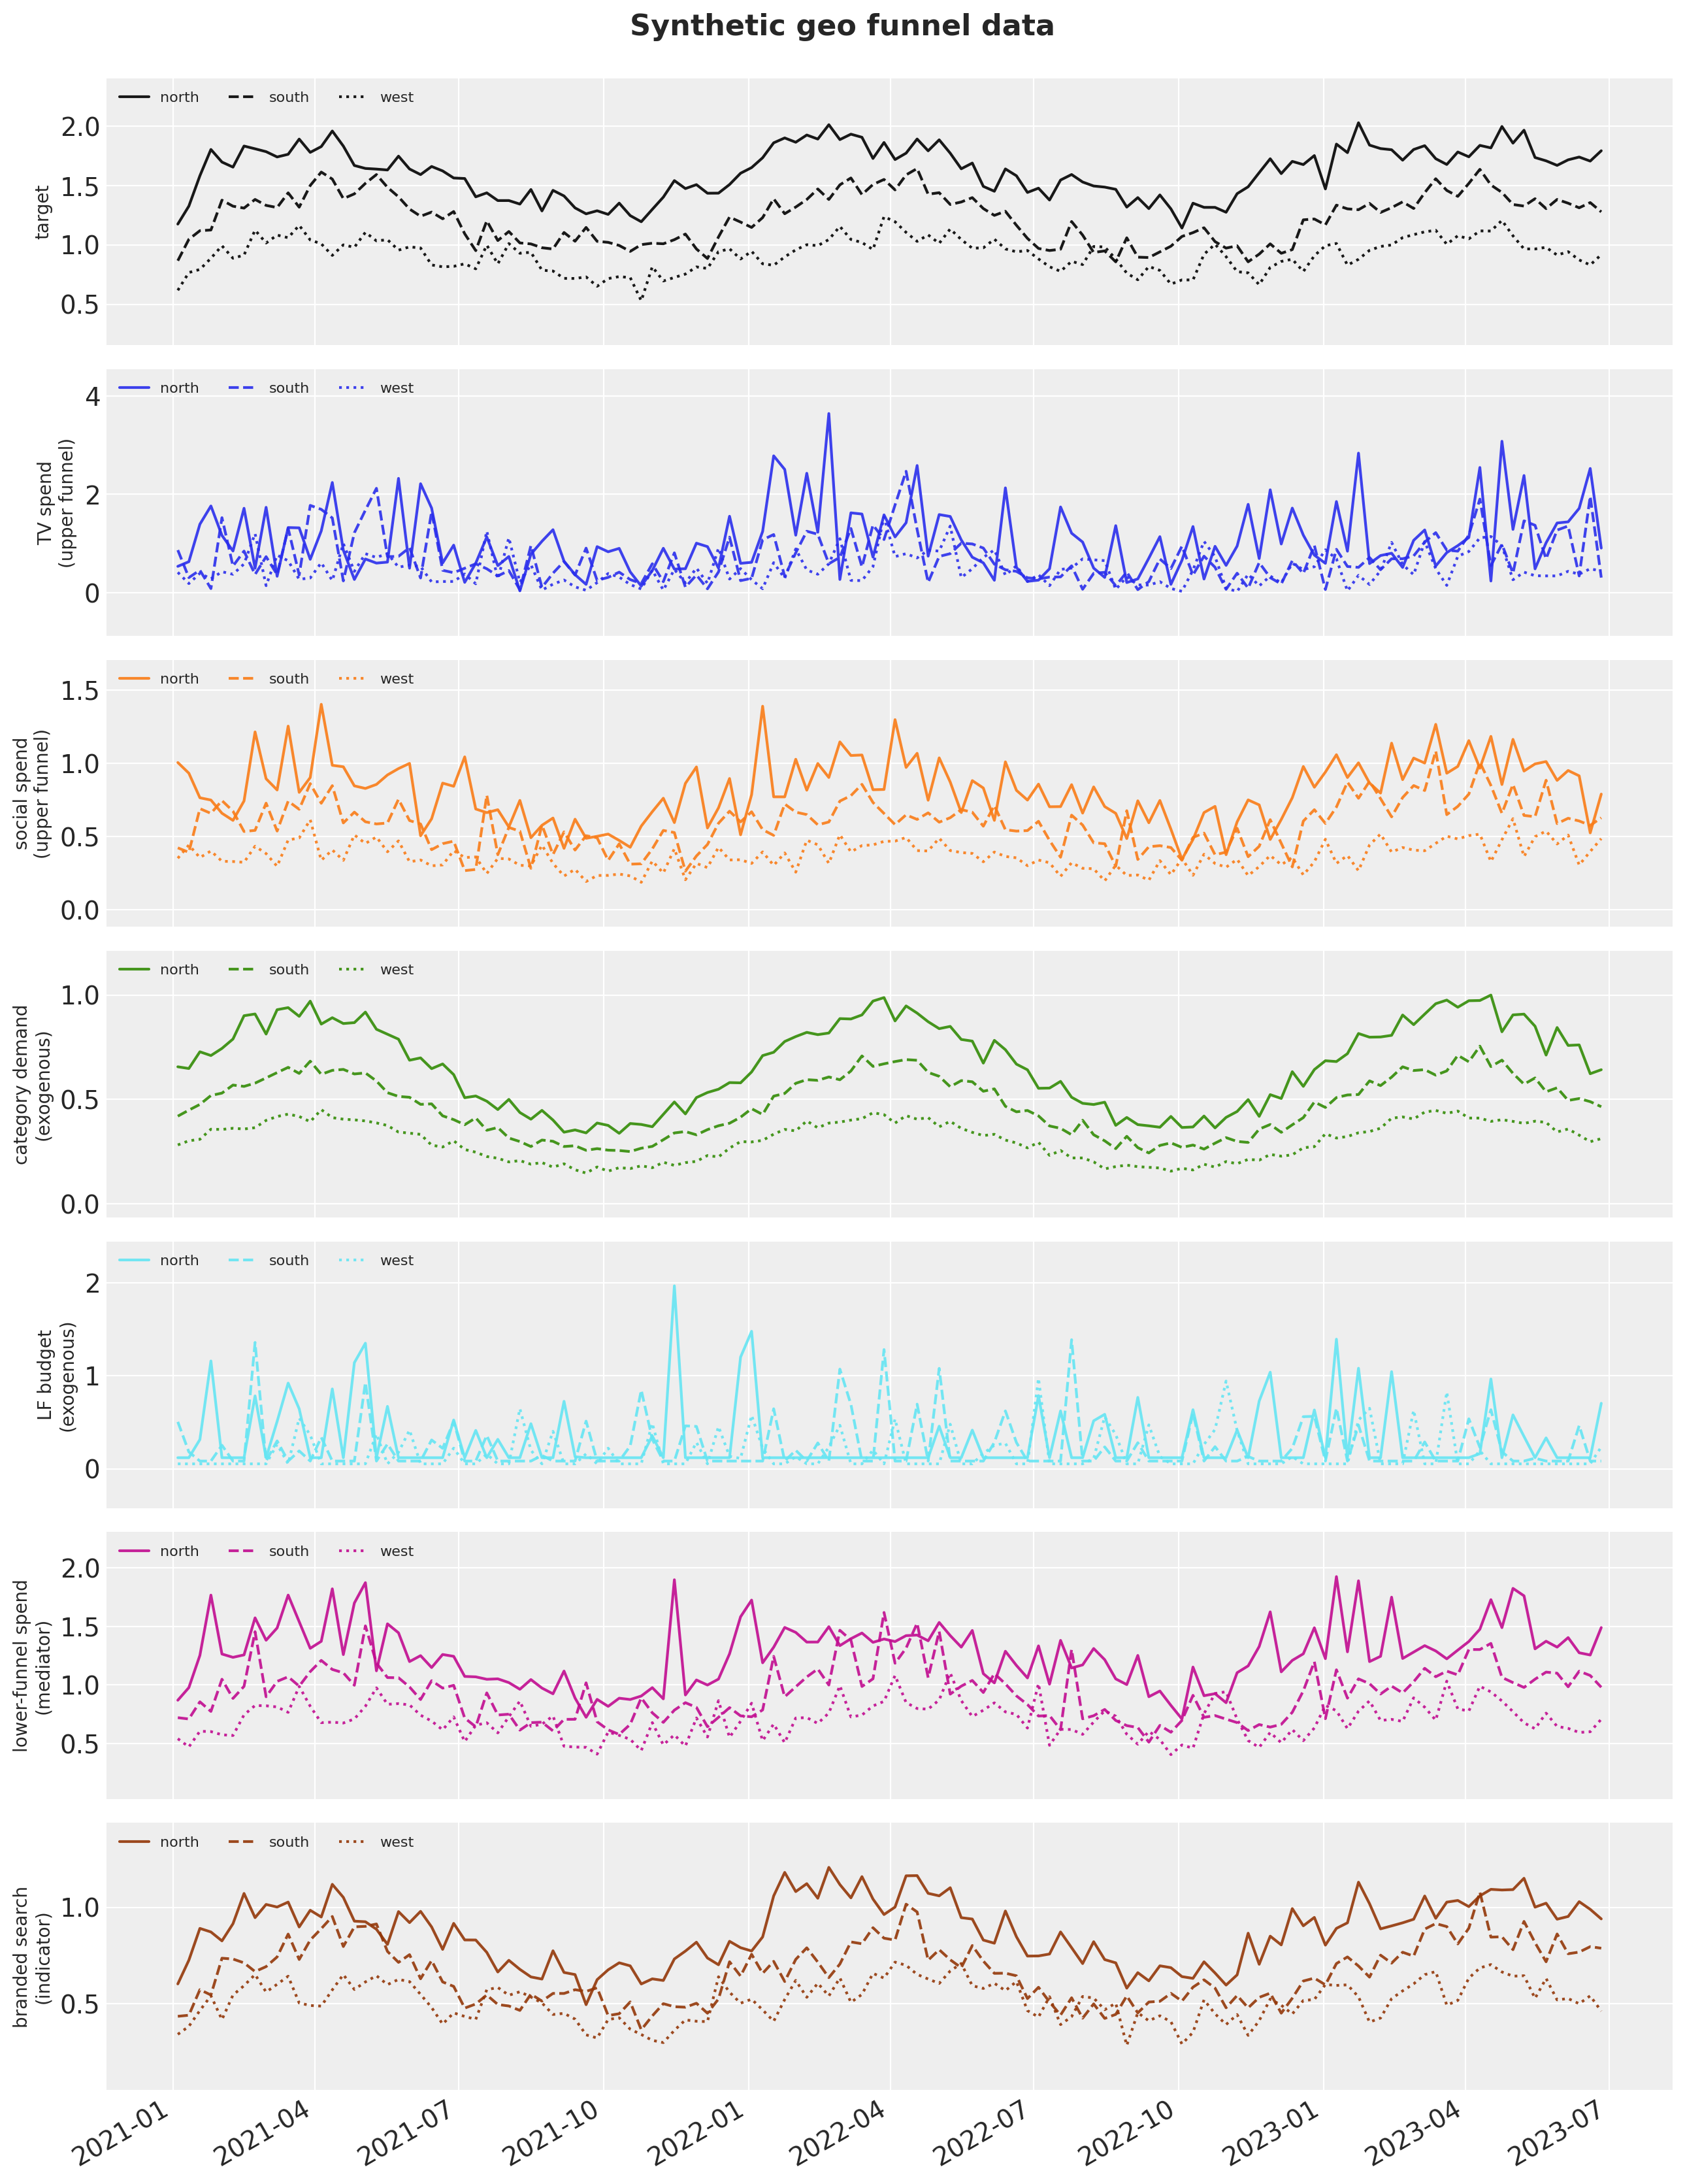

In [19]:
series = [
    ("y", "target", "black"),
    ("tv_spend", "TV spend\n(upper funnel)", "C0"),
    ("social_spend", "social spend\n(upper funnel)", "C1"),
    ("category_demand", "category demand\n(exogenous)", "C2"),
    ("lf_budget", "LF budget\n(exogenous)", "C5"),
    ("lower_spend", "lower-funnel spend\n(mediator)", "C3"),
    ("search_volume", "branded search\n(indicator)", "C4"),
]

fig, axes = plt.subplots(nrows=len(series), ncols=1, figsize=(13, 17), sharex=True)
for ax, (name, label, color) in zip(axes, series, strict=True):
    for geo, style in zip(geos, ["-", "--", ":"], strict=True):
        ax.plot(
            date_range,
            data[name].sel(geo=geo),
            linestyle=style,
            color=color,
            label=geo,
            alpha=0.9,
        )
    # The variable name lives in the y-label, not a title -- with seven stacked
    # panels, per-axes titles collide with the suptitle and with each other.
    ax.set_ylabel(label, fontsize=10)
    ax.margins(y=0.25)
    ax.legend(loc="upper left", ncols=3, fontsize=8, framealpha=0.6)
fig.suptitle("Synthetic geo funnel data", fontsize=16, fontweight="bold")
fig.autofmt_xdate()
fig.tight_layout(rect=(0, 0, 1, 0.98))

Zooming in on the latent layer shows how the pieces relate. Lower-funnel spend
sits *above* latent demand by the budget-driven wedge $\lambda_g B_{t,g}$, and the
reported series tracks that structural quantity up to reporting noise. Branded
search follows demand itself, scaled by $\kappa$.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_79659/3369902314.py:44: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.86))


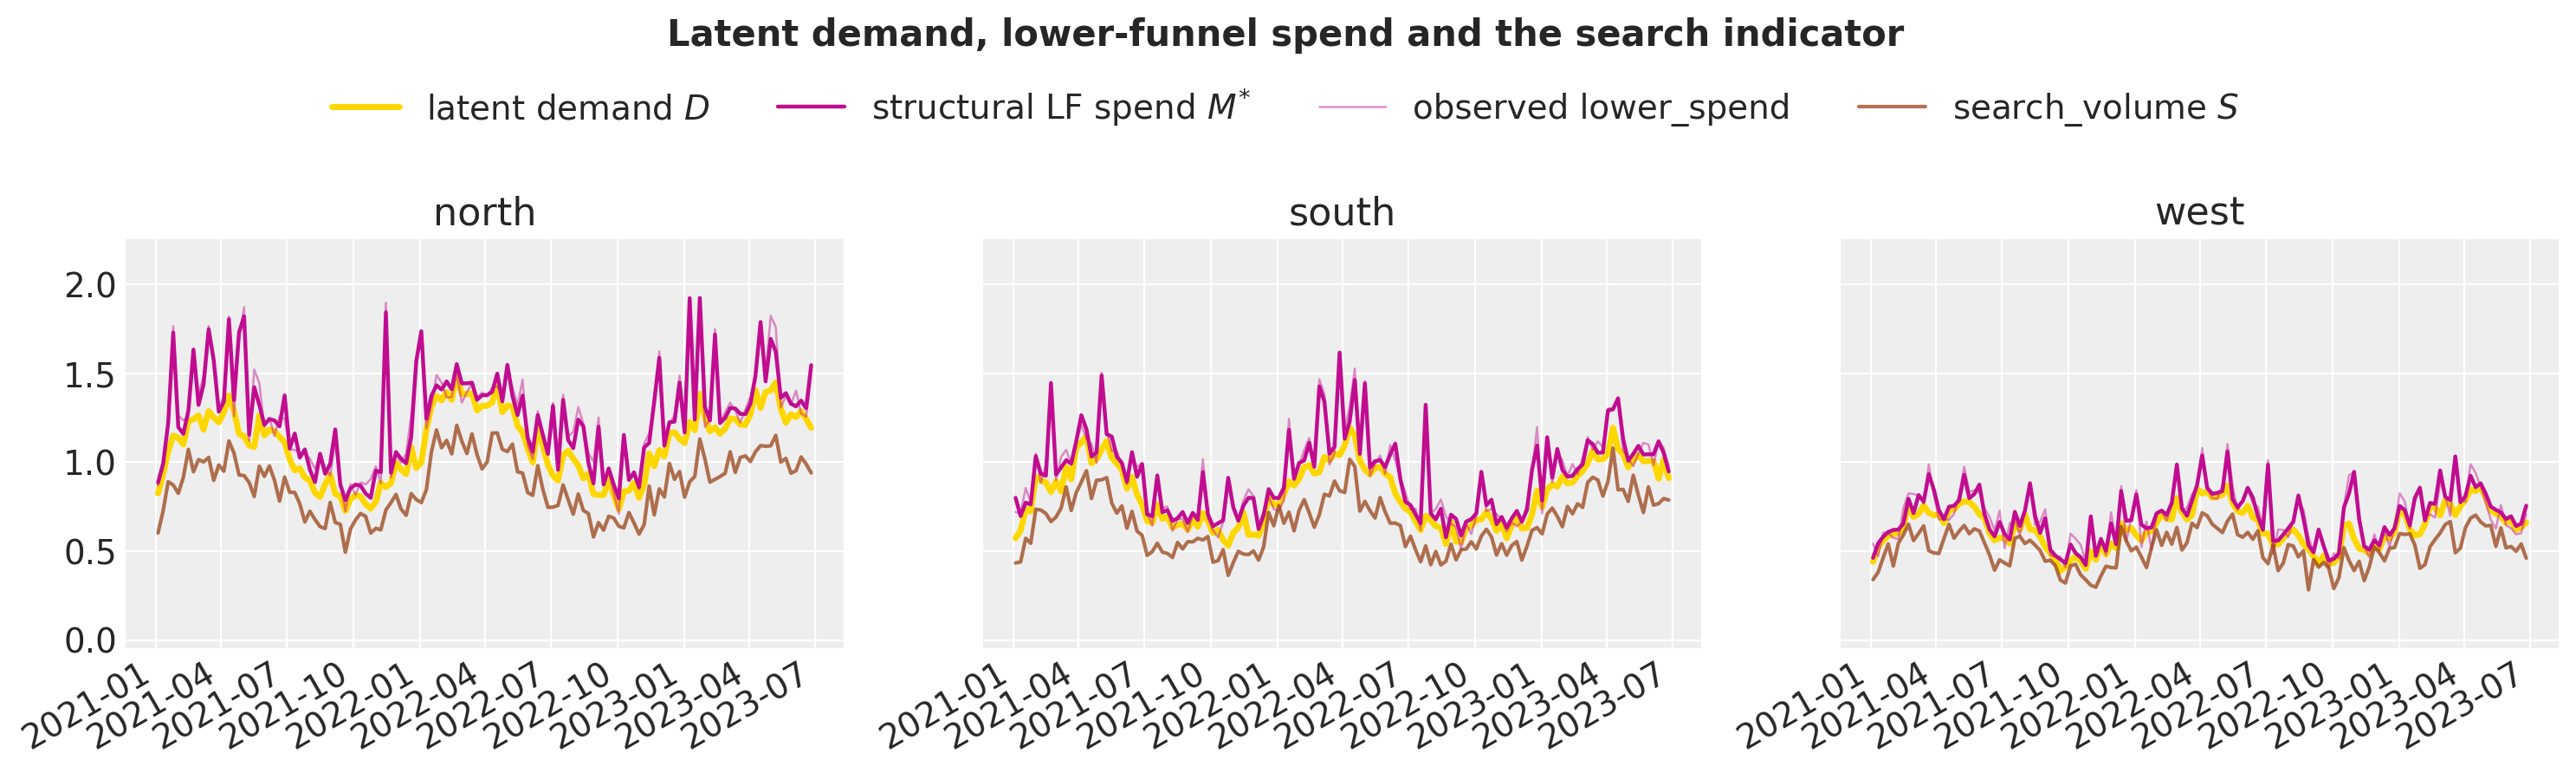

In [20]:
fig, axes = plt.subplots(ncols=len(geos), figsize=(15, 4.5), sharey=True)
for ax, geo in zip(axes, geos, strict=True):
    ax.plot(
        date_range,
        data["demand_true"].sel(geo=geo),
        color="gold",
        lw=2.5,
        label="latent demand $D$",
    )
    ax.plot(
        date_range,
        data["lf_spend_true"].sel(geo=geo),
        color="C3",
        lw=1.6,
        label="structural LF spend $M^{*}$",
    )
    ax.plot(
        date_range,
        data["lower_spend"].sel(geo=geo),
        color="C3",
        alpha=0.45,
        lw=0.9,
        label="observed lower_spend",
    )
    ax.plot(
        date_range,
        data["search_volume"].sel(geo=geo),
        color="C4",
        alpha=0.7,
        label="search_volume $S$",
    )
    ax.set_title(geo)
    ax.margins(y=0.2)
# One figure-level legend, placed under the title: a per-axes legend sits on top of
# the lines in every panel.
handles, labels = axes[0].get_legend_handles_labels()
fig.suptitle(
    "Latent demand, lower-funnel spend and the search indicator",
    fontsize=15,
    fontweight="bold",
)
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.93), ncols=4)
fig.autofmt_xdate()
fig.tight_layout(rect=(0, 0, 1, 0.86))

## Fitting the models

We fit four models on the synthetic data:

- **Naive A** -- a standard geo MMM with the mediator thrown in as an **ordinary
  channel** alongside the two upper-funnel channels.
- **Naive B** -- a standard geo MMM with the mediator **omitted**.
- **Naive C** -- a standard geo MMM with **branded search volume** as a channel.
- **Funnel** -- the joint model with the `FunnelEffect`.

All four share adstock/saturation families, priors, scaling and sampler settings,
so any difference in their conclusions comes from the structure alone.

In [21]:
frame = (
    data[["tv_spend", "social_spend", "lower_spend", "search_volume", "y"]]
    .to_dataframe()
    .reset_index()
)

X_upper = frame[["date", "geo", *channels]]
X_with_mediator = frame[["date", "geo", *channels, "lower_spend"]]
X_with_search = frame[["date", "geo", *channels, "search_volume"]]
y = frame["y"]

sample_kwargs = dict(
    chains=4, tune=1_000, draws=1_000, target_accept=0.95, random_seed=rng
)
sampler_config = {"nuts_sampler": "nutpie"}

### Naive A: mediator as an ordinary channel

This is what most production MMMs do when they have upper- and lower-funnel spend
in the same table: list them side by side. It is not an unreasonable model -- in
this DAG lower-funnel spend really does drive the target, so the coefficient it
estimates is a real thing. The problem is what the model does *not* say:
conditioning on the mediator **blocks the indirect path**, so the upper channels
are credited with at most their direct effect and the lower-funnel channel keeps
the credit for demand they created.

In [22]:
naive_a = make_mmm([*channels, "lower_spend"], sampler_config=sampler_config)
naive_a.build_model(X_with_mediator, y)
naive_a.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_a.fit(X_with_mediator, y, **sample_kwargs)
naive_a.sample_posterior_predictive(X_with_mediator, random_seed=rng);

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### Naive B: mediator omitted

Here the two upper channels are the only media. Each response curve has to absorb
both the direct effect and the demand created downstream -- and, because there is
no mediator, the seasonal category demand that moves the target has nowhere to go
either. Whichever channel co-moves most with category demand will collect it.

In [23]:
naive_b = make_mmm(channels, sampler_config=sampler_config)
naive_b.build_model(X_upper, y)
naive_b.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_b.fit(X_upper, y, **sample_kwargs)
naive_b.sample_posterior_predictive(X_upper, random_seed=rng);

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### Naive C: the indicator as a channel

Branded search volume is the most tempting variable in the whole dataset. It
correlates beautifully with sales, it is free, and it arrives weekly. So it ends up
in the channel list.

It causes nothing. Because it is a **descendant of latent demand**, conditioning on
it blocks $U \to D \to M^{*} \to Y$ just as surely as conditioning on the mediator
itself would -- textbook post-treatment conditioning, on a variable that has no
causal role at all.

In [24]:
naive_c = make_mmm([*channels, "search_volume"], sampler_config=sampler_config)
naive_c.build_model(X_with_search, y)
naive_c.add_original_scale_contribution_variable(var=["channel_contribution", "y"])
naive_c.fit(X_with_search, y, **sample_kwargs)
naive_c.sample_posterior_predictive(X_with_search, random_seed=rng);

NUTS[nutpie]: [y_sigma, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution]


Output()

Output()

Sampling: [y]


Output()

### The funnel model

The funnel model has the two upper channels (their direct effects) plus the
`FunnelEffect`, which reads the mediator data from the `Dataset` and fits the
target and both proxies jointly. Note the plumbing discussed earlier: we build
from the `Dataset` and fit with the long frame.

In [25]:
ds_fit = make_dataset(
    media_raw, lower_spend_obs, search_obs, category_demand, lf_budget
)
y_fit = xr.DataArray(y_obs, dims=("date", "geo"), coords=coords)

funnel = make_mmm(channels, sampler_config=sampler_config)
funnel.add_mu_effect(make_funnel_effect())
funnel.build_model(X=ds_fit, y=y_fit)
funnel.add_original_scale_contribution_variable(
    var=["channel_contribution", "funnel_effect_contribution", "y"]
)
funnel.fit(X=X_upper, y=y, **sample_kwargs)
funnel.sample_posterior_predictive(X_upper, random_seed=rng);

NUTS[nutpie]: [y_sigma, adstock_lf_alpha, funnel_lambda, adstock_uf_alpha, sat_uf_lam, sat_uf_beta, funnel_gamma, funnel_baseline, sat_lf_lam, sat_lf_beta, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, intercept_contribution, funnel_sigma_s, funnel_kappa, funnel_sigma_m]


Output()

Output()

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [funnel_lower_spend_likelihood, funnel_search_likelihood, y]


Output()

### Diagnostics

In [26]:
models = {
    "Naive A": naive_a,
    "Naive B": naive_b,
    "Naive C": naive_c,
    "Funnel": funnel,
}

# Scalar parameters only. Summarising every deterministic would pull in the
# date x geo arrays (`funnel_demand`, `funnel_lf_spend`, the contributions) and
# dominate the runtime of this cell.
scalar_params = [
    "intercept_contribution",
    "adstock_alpha",
    "saturation_lam",
    "saturation_beta",
    "gamma_fourier",
    "y_sigma",
    "funnel_baseline",
    "funnel_gamma",
    "funnel_lambda",
    "funnel_kappa",
    "funnel_sigma_m",
    "funnel_sigma_s",
    "adstock_uf_alpha",
    "sat_uf_lam",
    "sat_uf_beta",
    "adstock_lf_alpha",
    "sat_lf_lam",
    "sat_lf_beta",
]

for label, model in models.items():
    present = [v for v in scalar_params if v in model.idata.posterior]
    divergences = int(model.idata["sample_stats"]["diverging"].sum())
    max_rhat = float(az.summary(model.idata, var_names=present)["r_hat"].max())
    print(f"{label:8s} | divergences: {divergences:3d} | max r-hat: {max_rhat:.3f}")

Naive A  | divergences:   0 | max r-hat: 1.000
Naive B  | divergences:   0 | max r-hat: 1.010
Naive C  | divergences:   0 | max r-hat: 1.000


Funnel   | divergences:   0 | max r-hat: 1.000


### Posterior predictive checks

The funnel model has **three** observed quantities. All of them should be well
recovered.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_79659/3064146725.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0.01, 0, 1, 0.97))


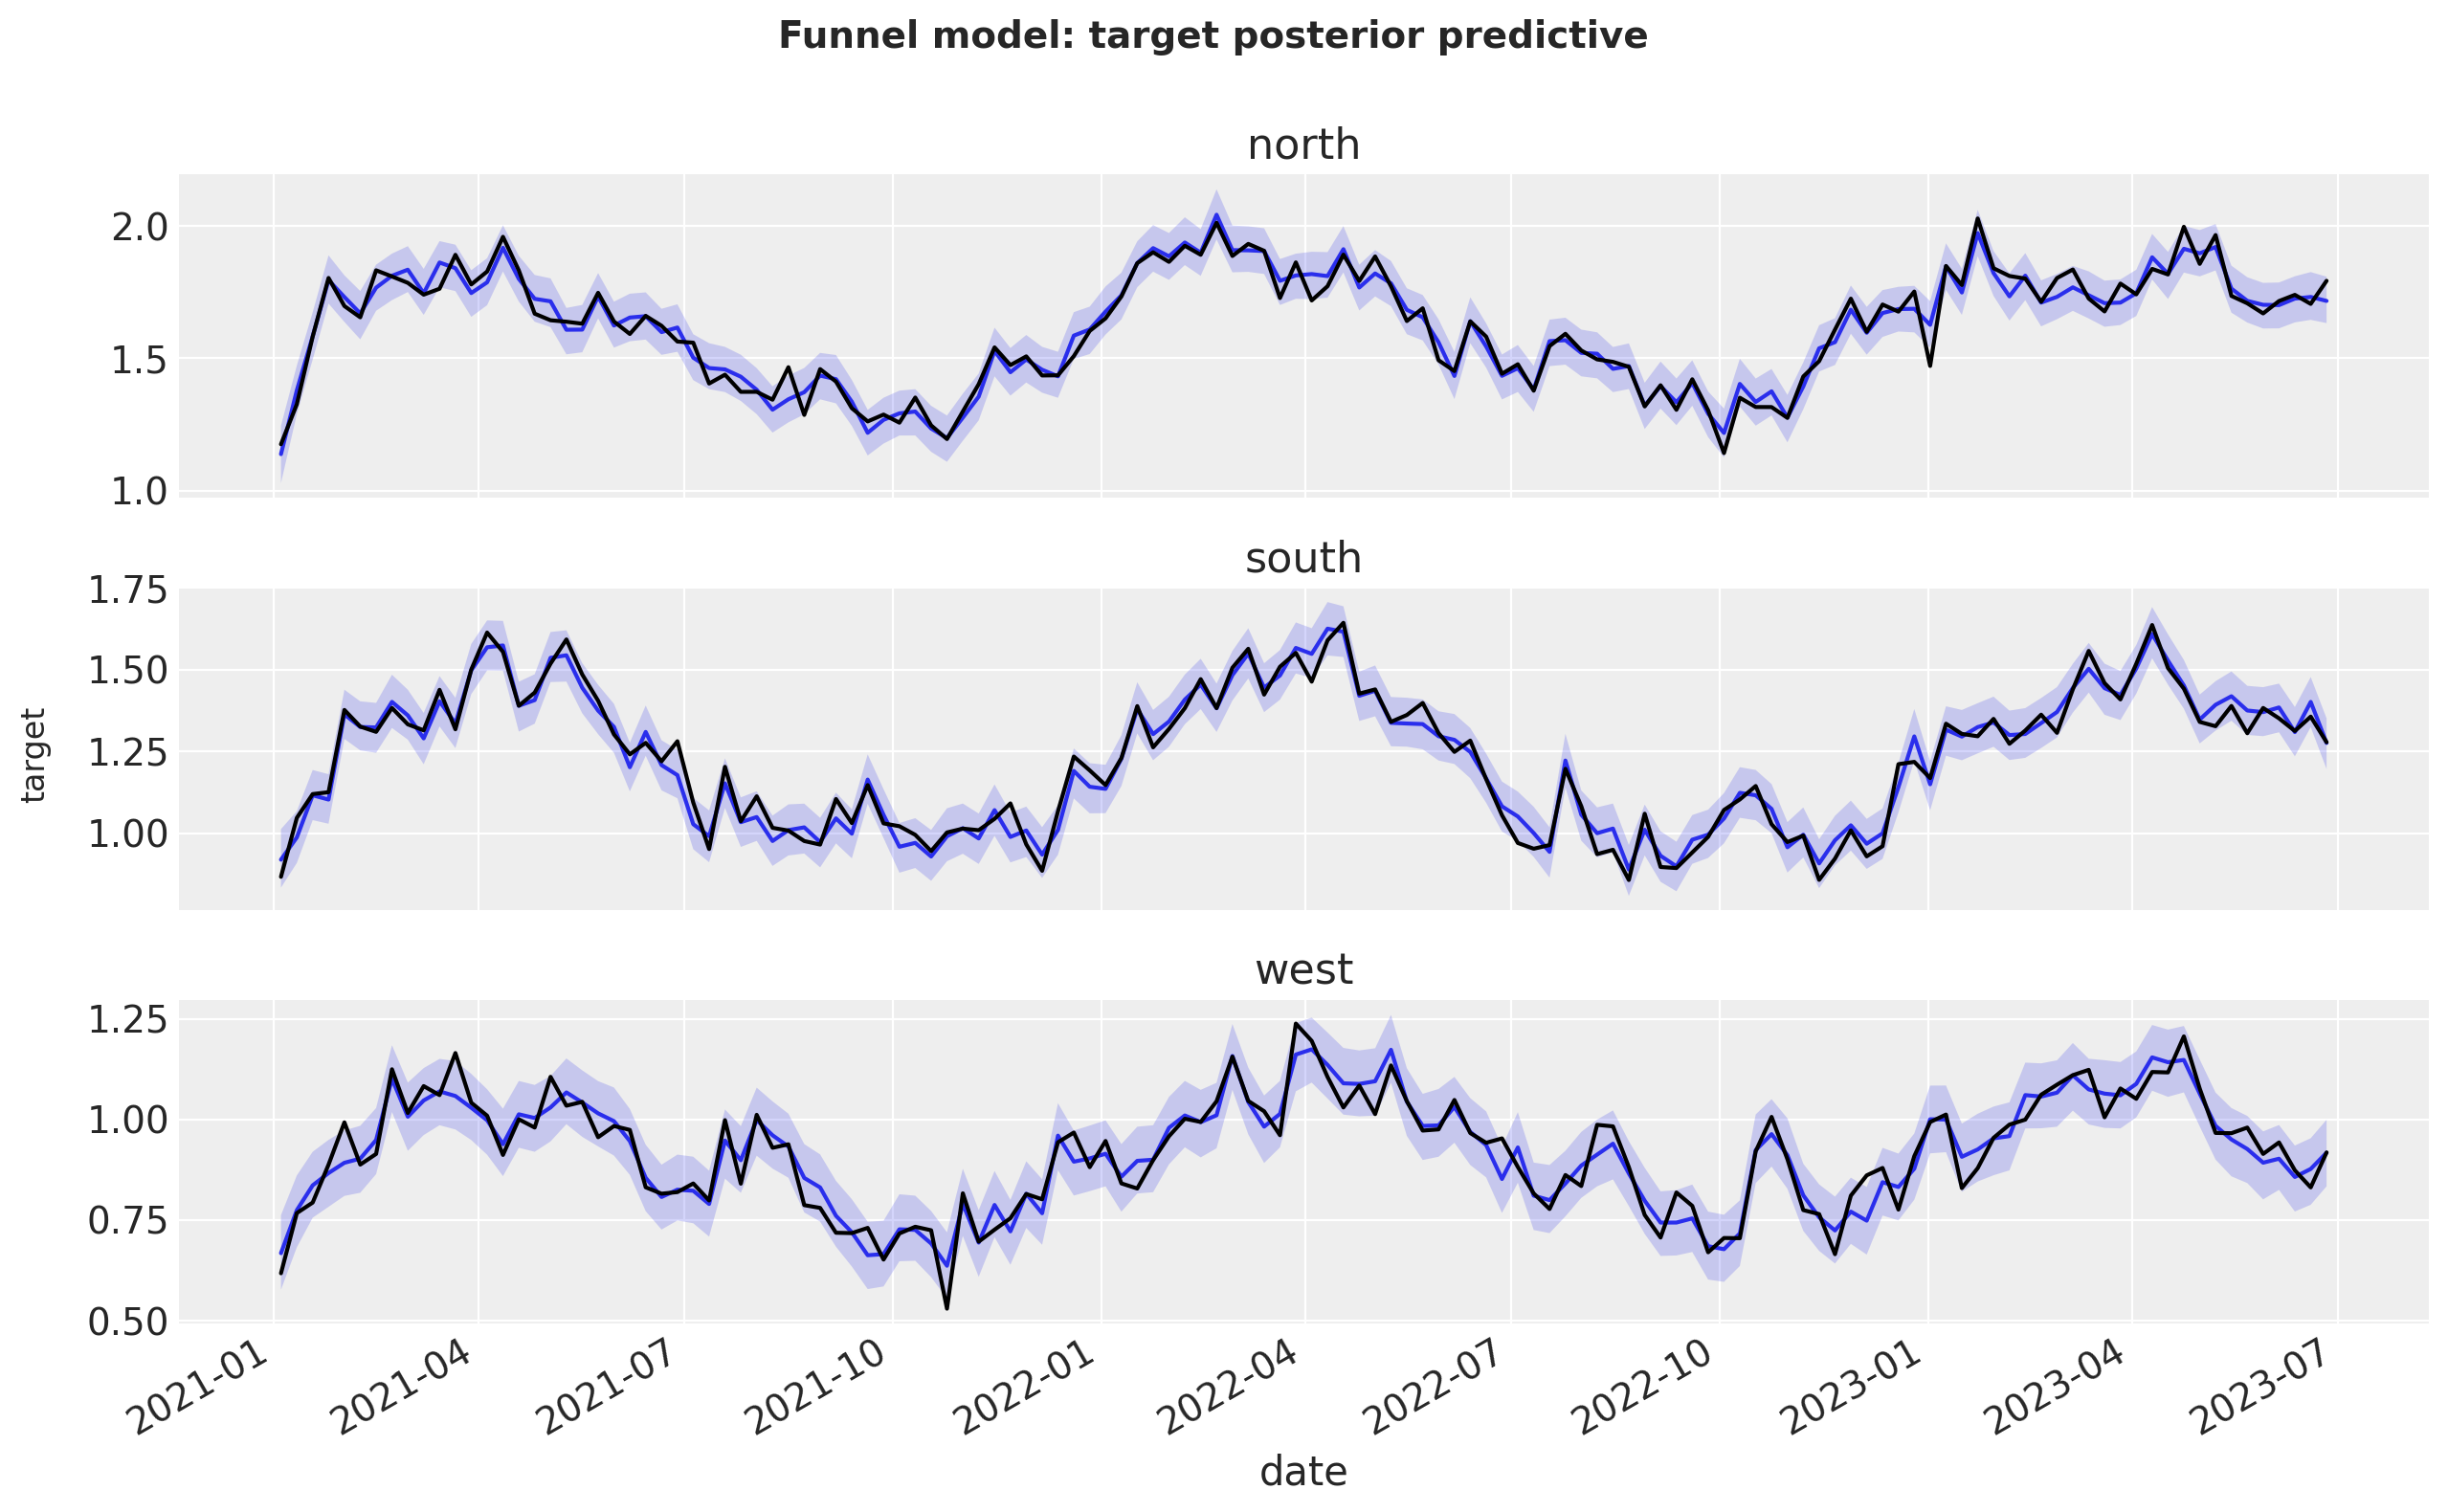

In [27]:
funnel.plot_suite = "new"

# `return_as_pc` gives back the PlotCollection instead of (fig, axes), so panels can
# be addressed by coordinate label rather than by position in `fig.get_axes()`.
pc = funnel.plot.diagnostics.posterior_predictive(
    hdi_prob=0.94, return_as_pc=True, figsize=(13, 8)
)
fig = pc.viz["figure"].item()

for i, geo in enumerate(geos):
    ax = pc.viz["plot"].sel(geo=geo).item()
    # The built-in labels every panel "Date" / "Posterior Predictive"; repeated on a
    # stacked geo facet they collide and spill outside the axes.
    ax.set_xlabel("date" if i == len(geos) - 1 else "")
    ax.set_ylabel("")
    ax.set_title(geo)

fig.supylabel("target")
fig.suptitle(
    "Funnel model: target posterior predictive", fontsize=14, fontweight="bold"
)
fig.autofmt_xdate()
fig.tight_layout(rect=(0.01, 0, 1, 0.97))

The other two are the effect's own likelihoods. There is no built-in for these:
`diagnostics.posterior_predictive` targets the model's `y` variable specifically,
so a custom likelihood declared inside a `MuEffect` has to be plotted by hand.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_79659/4010075878.py:34: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


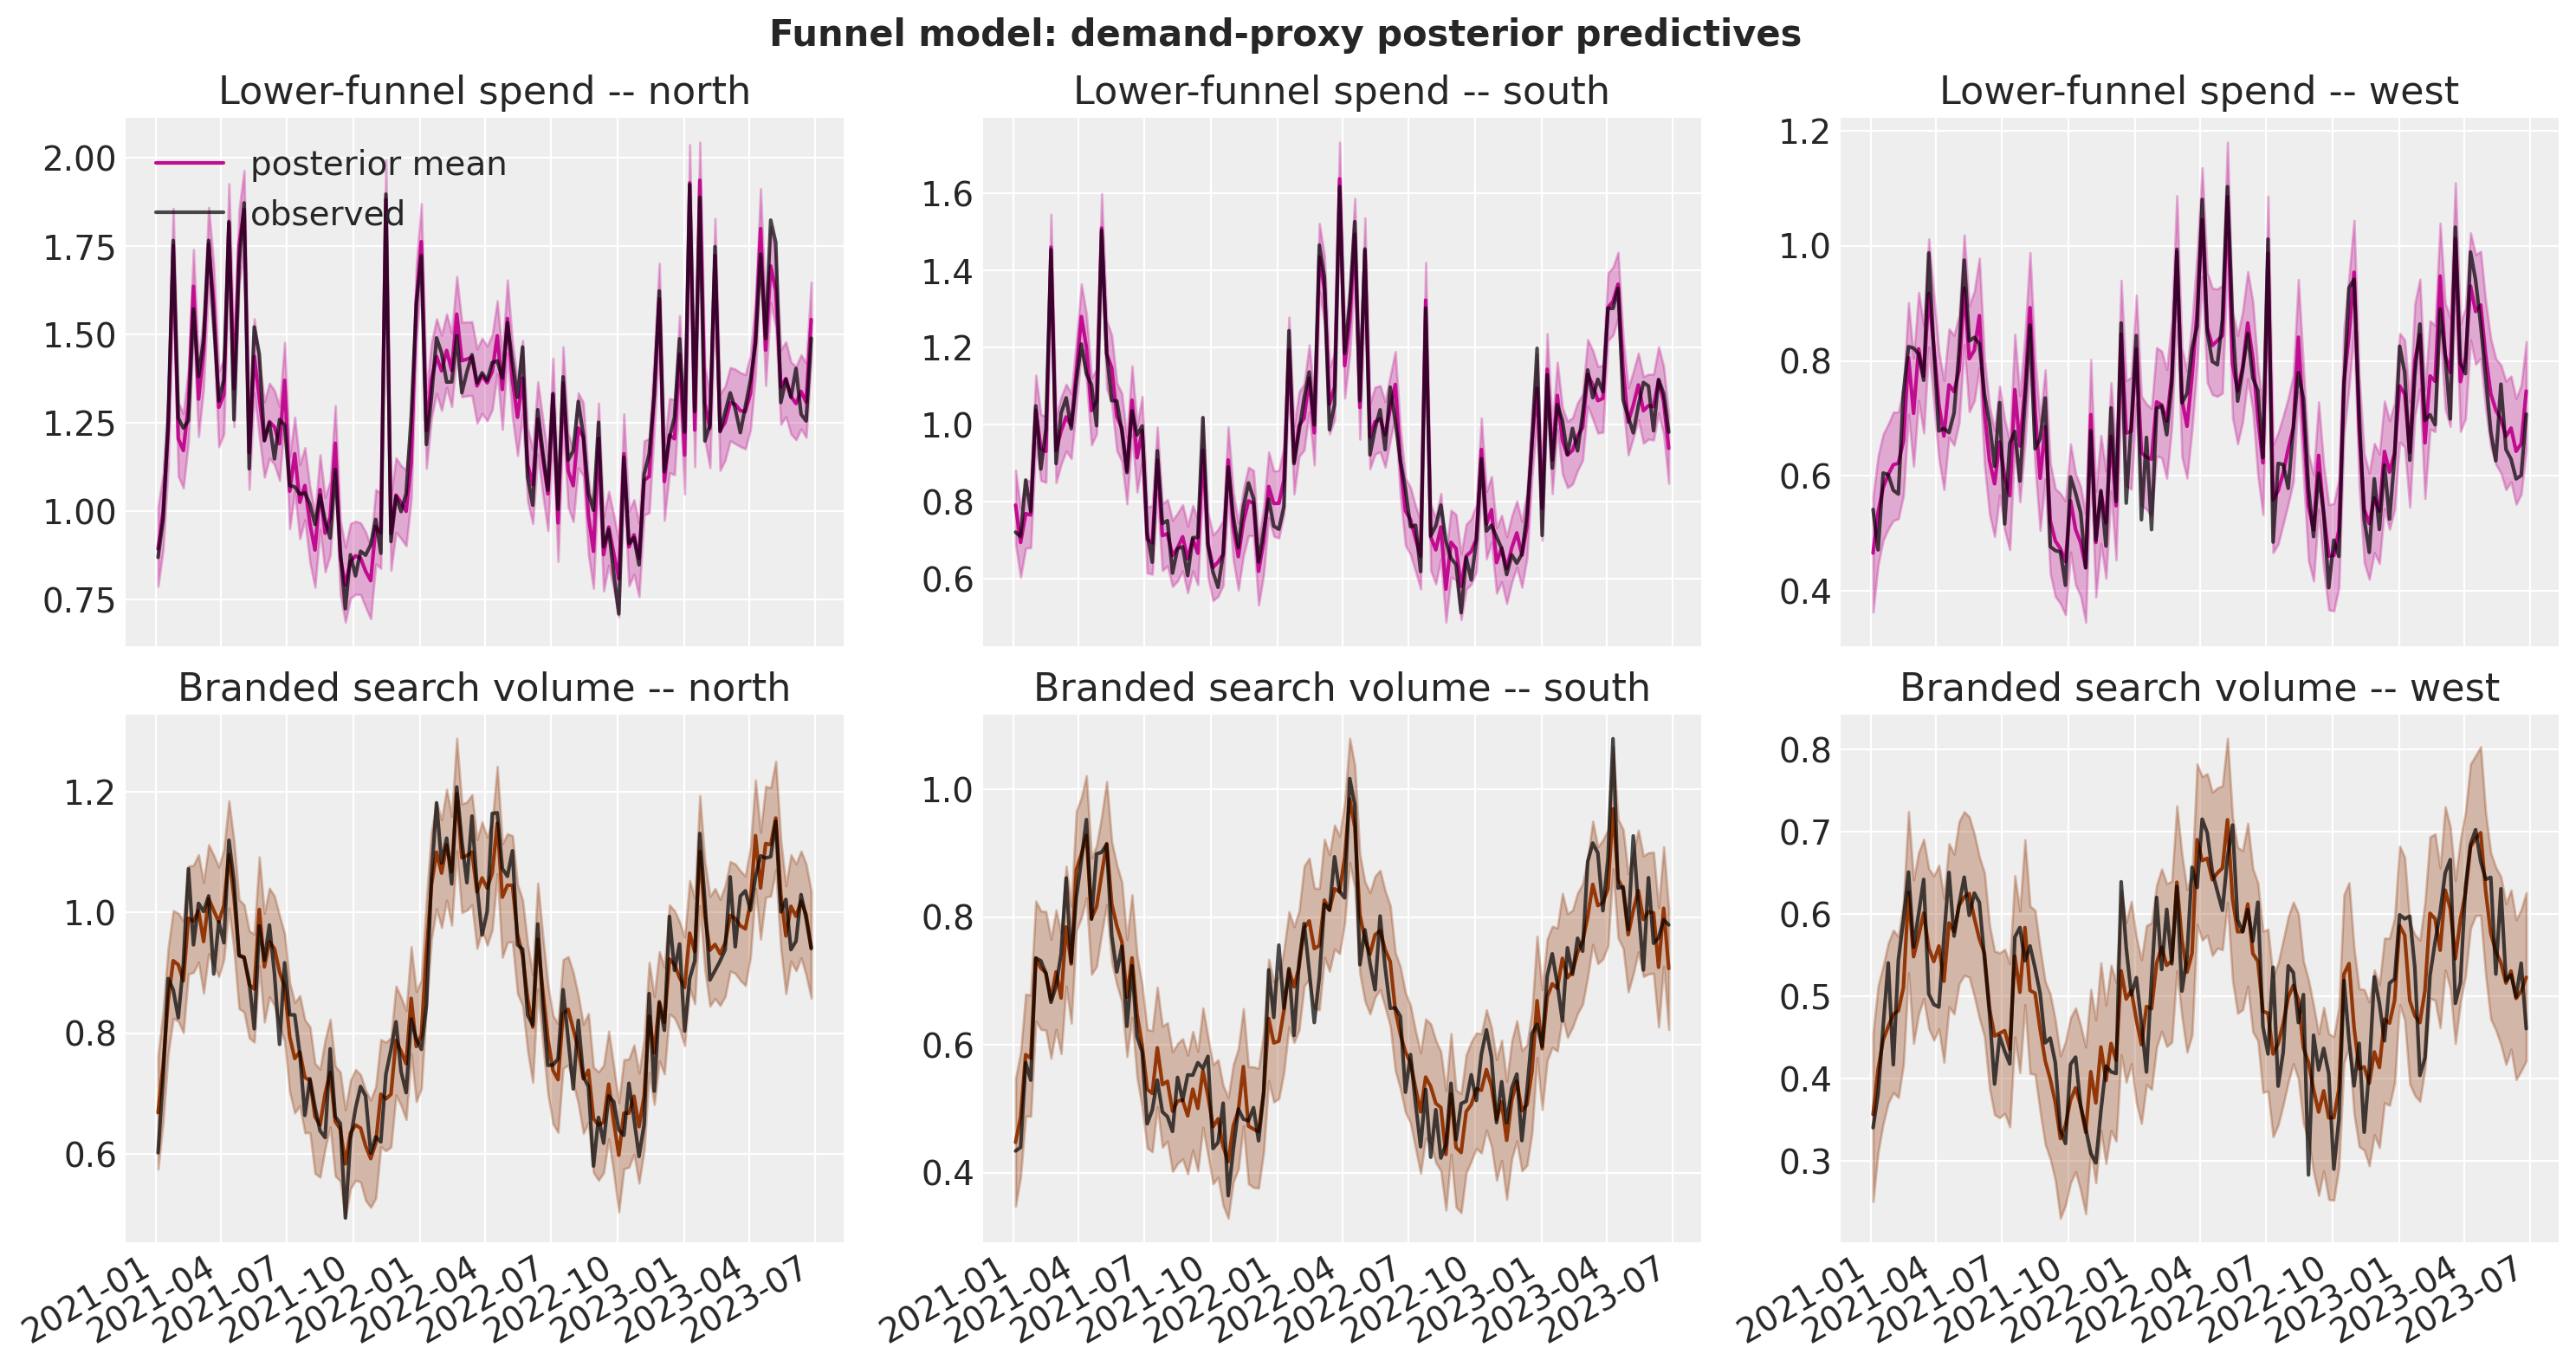

In [28]:
proxies = [
    ("funnel_lower_spend_likelihood", "lower_spend", "Lower-funnel spend", "C3"),
    ("funnel_search_likelihood", "search_volume", "Branded search volume", "C4"),
]

fig, axes = plt.subplots(
    nrows=len(proxies), ncols=len(geos), figsize=(15, 8), sharex=True
)
for row, (var, observed, title, color) in enumerate(proxies):
    pp = funnel.idata.posterior_predictive[var]
    lo, hi = hdi_bounds(pp)
    mean = pp.mean(dim=["chain", "draw"])
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        ax.fill_between(
            date_range, lo.sel(geo=geo), hi.sel(geo=geo), alpha=0.3, color=color
        )
        ax.plot(date_range, mean.sel(geo=geo), color=color, label="posterior mean")
        ax.plot(
            date_range,
            data[observed].sel(geo=geo),
            color="black",
            alpha=0.7,
            label="observed",
        )
        ax.set(title=f"{title} -- {geo}")
axes[0, 0].legend(loc="upper left")
fig.suptitle(
    "Funnel model: demand-proxy posterior predictives",
    fontsize=15,
    fontweight="bold",
)
fig.autofmt_xdate()
fig.tight_layout()

## Parameter recovery

Because we generated the data we can check the funnel model against the truth.
One subtlety carries over from the basic notebook and gets slightly more involved
here: the `MMM` fits on an internally scaled target, so every parameter that acts
on the **scale of the target mean** -- the intercept, the two saturation
amplitudes and the Fourier coefficients -- must be multiplied by `target_scale`
before comparing with the ground truth. With `dims=()` scaling that factor is
**per geo**, and `xarray` applies it by label for us. Parameters acting on the
*inputs* (adstock decays, saturation curvatures) or on the *mediator* scale
(everything in the demand equation) are scale-free and compare directly.

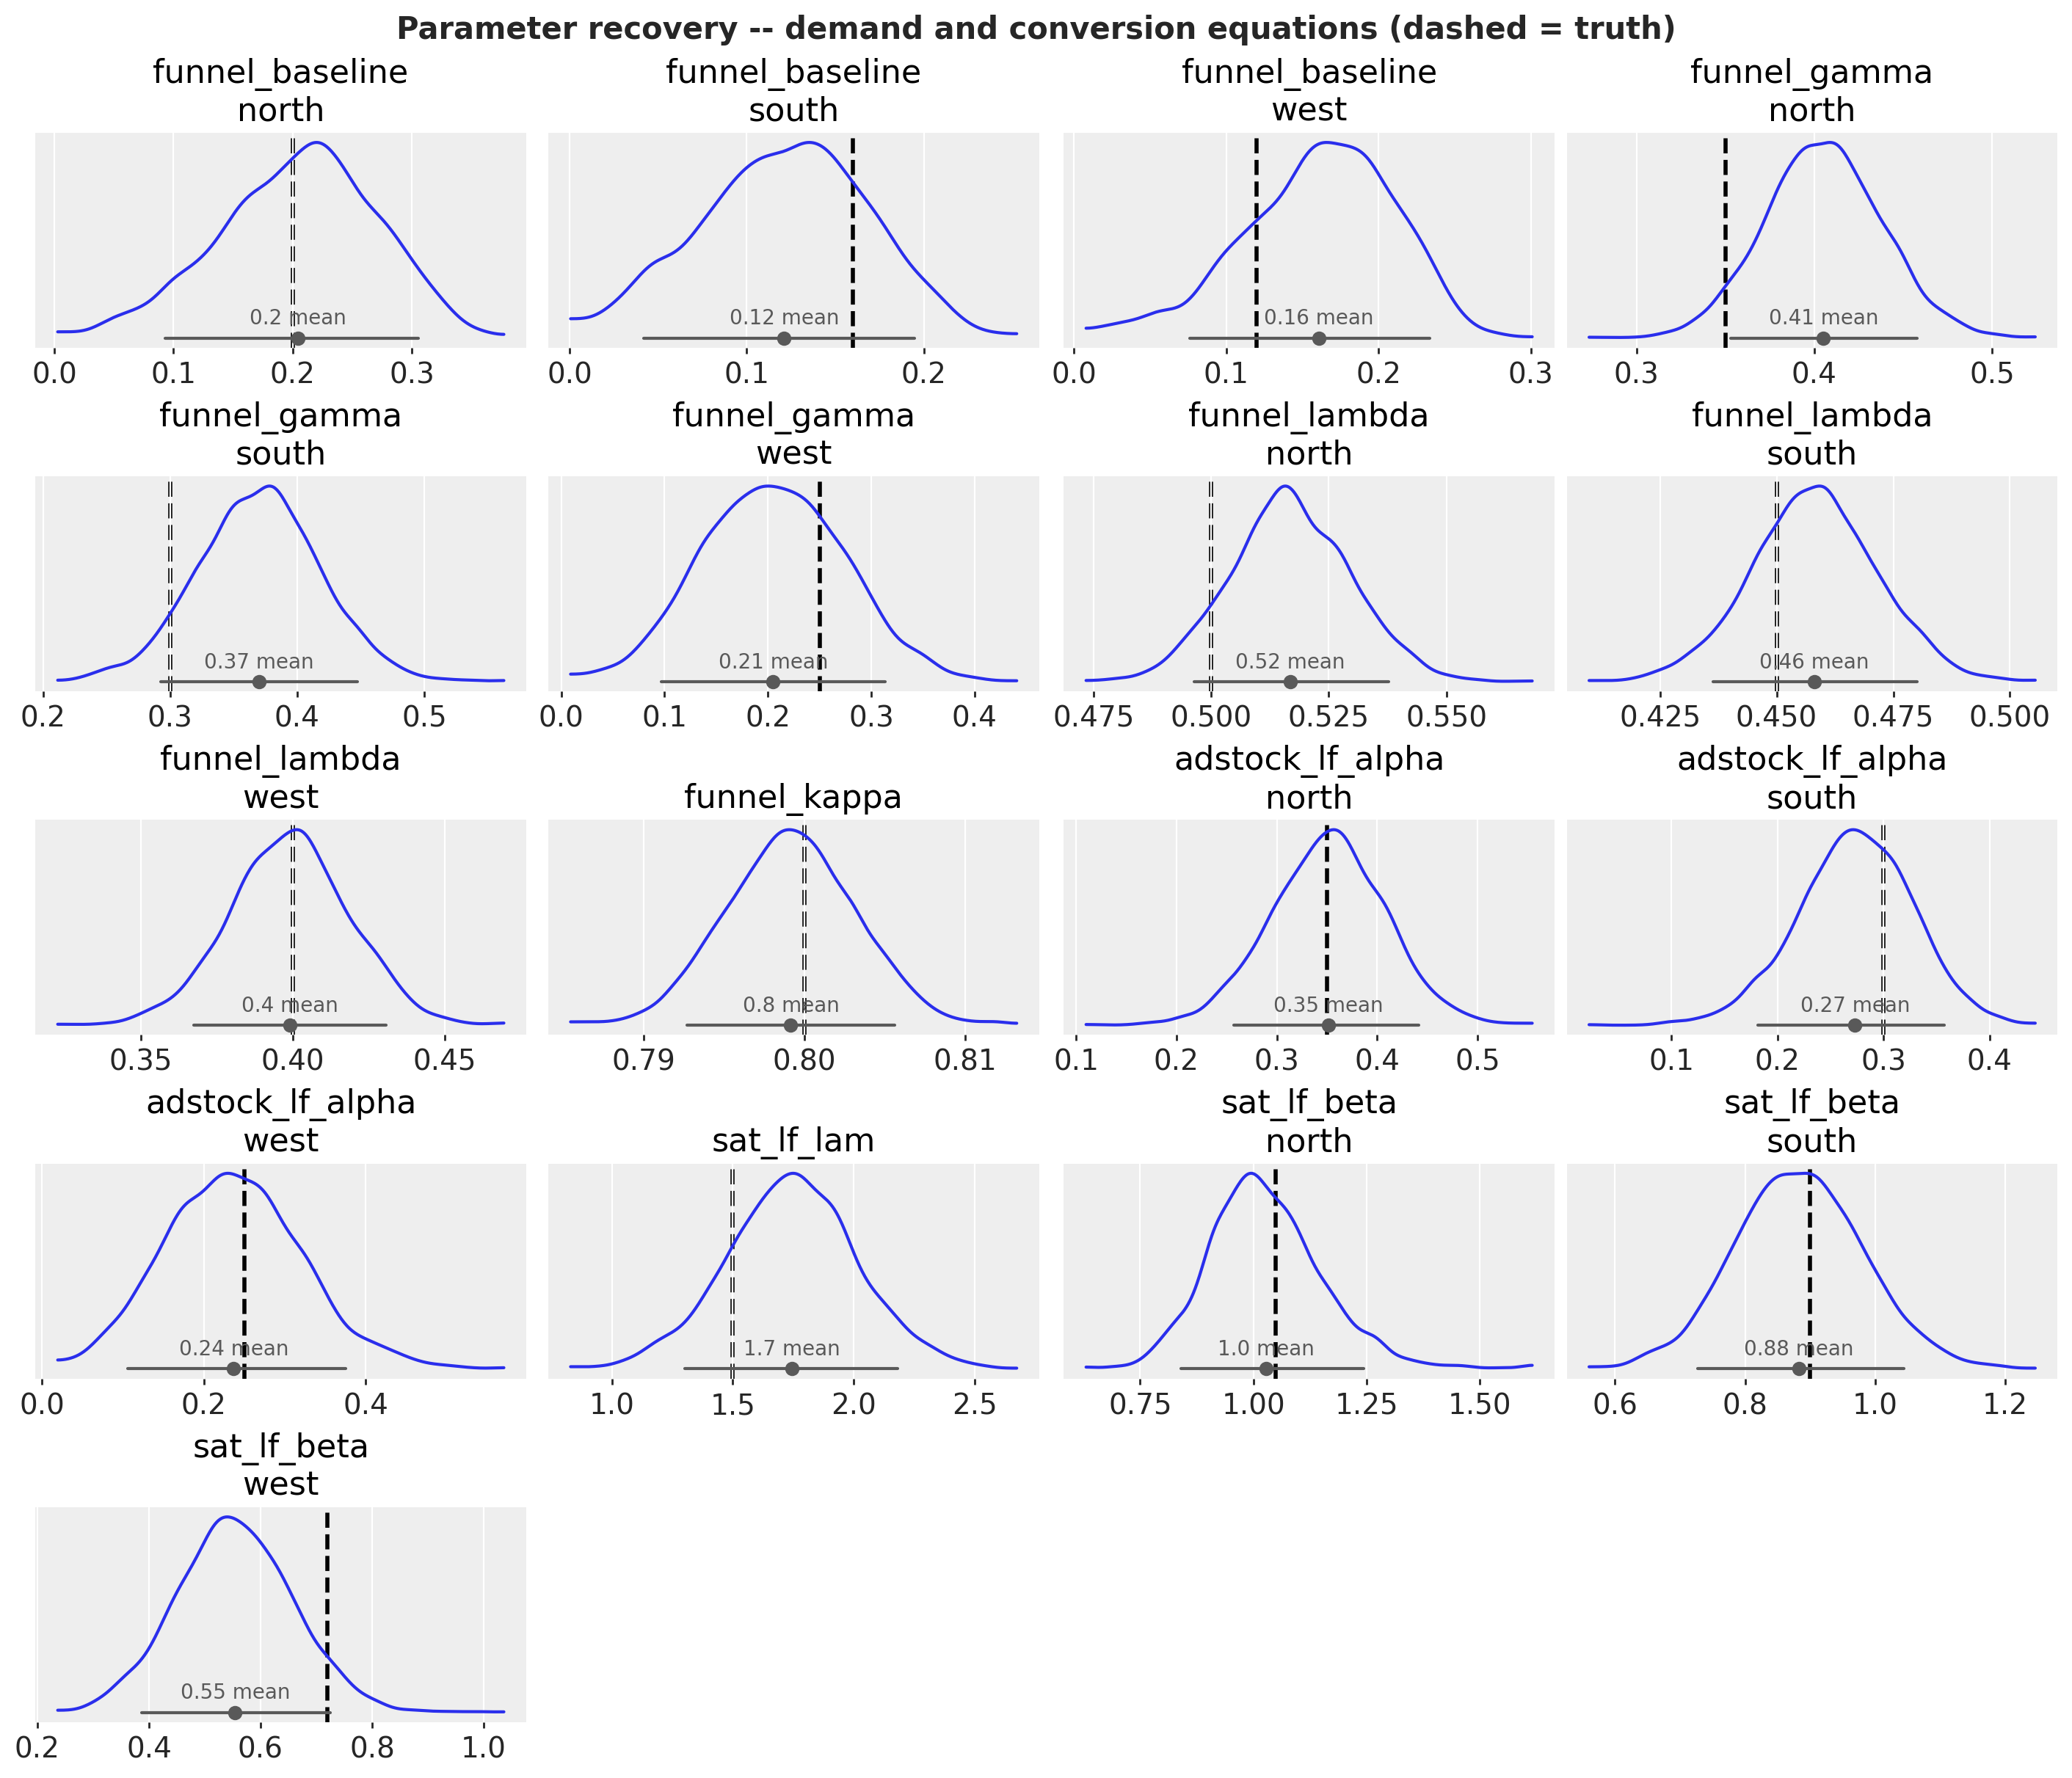

In [29]:
target_scale = funnel.idata.constant_data["target_scale"]
mu_scale_vars = {
    "intercept_contribution",
    "saturation_beta",
    "sat_lf_beta",
    "gamma_fourier",
}

posterior_on_true_scale = xr.Dataset(
    {
        var: (draws * target_scale if var in mu_scale_vars else draws)
        for var, draws in funnel.idata.posterior.data_vars.items()
    }
)
recovery_idata = xr.DataTree.from_dict(
    {"posterior": xr.DataTree(posterior_on_true_scale)}
)


def truth_dataset(var_names: list[str]) -> xr.Dataset:
    """Ground truth for ``var_names`` as a Dataset matching the posterior's dims."""
    labels = {"geo": geos, "channel": channels}
    out = {}
    for var in var_names:
        dims = funnel.model.named_vars_to_dims.get(var) or ()
        out[var] = xr.DataArray(
            true[var], dims=dims, coords={d: labels[d] for d in dims}
        )
    return xr.Dataset(out)


def recovery_plot(var_names: list[str], title: str, figsize: tuple[float, float]):
    """Posterior KDEs from the built-in plot suite, with true values overlaid."""
    pc = funnel.plot.diagnostics.posterior(
        var_names=var_names,
        idata=recovery_idata,
        return_as_pc=True,
        figure_kwargs={"figsize": figsize, "layout": "constrained"},
    )
    # `add_lines` accepts a Dataset of reference values and aligns it to each panel
    # by dimension, so per-geo and per-channel truths land in the right facets.
    azp.add_lines(
        pc,
        truth_dataset(var_names),
        visuals={"ref_line": {"color": "black", "linestyle": "--", "linewidth": 2}},
    )
    fig = pc.viz["figure"].item()
    fig.suptitle(title, fontsize=15, fontweight="bold")
    return pc


recovery_plot(
    [
        "funnel_baseline",
        "funnel_gamma",
        "funnel_lambda",
        "funnel_kappa",
        "adstock_lf_alpha",
        "sat_lf_lam",
        "sat_lf_beta",
    ],
    "Parameter recovery -- demand and conversion equations (dashed = truth)",
    (14, 12),
);

The parameters that carry the new structure are recovered sharply. `funnel_lambda`
and `funnel_kappa` in particular are pinned down tightly, which is what we want:
they are the two loadings that decide how much of lower-funnel spend is
demand-driven and how strongly branded search tracks demand.

It is worth checking that $\lambda$ is genuinely *identified* rather than simply
returning its prior -- an unidentified parameter still produces a posterior that
happily brackets the truth. Two things to look at: how much the data sharpened it
relative to the prior, and whether it traded off against the demand baseline it
shares a level with.

In [30]:
prior_lambda_sd = 0.5 * np.sqrt(1 - 2 / np.pi)  # sd of HalfNormal(sigma=0.5)
lambda_draws = funnel.idata.posterior["funnel_lambda"]

identification = pd.DataFrame(
    {
        "posterior mean": lambda_draws.mean(dim=["chain", "draw"]).to_series(),
        "true": pd.Series(true["funnel_lambda"], index=geos),
        "posterior sd / prior sd": (
            lambda_draws.std(dim=["chain", "draw"]) / prior_lambda_sd
        ).to_series(),
        "corr(lambda, baseline)": pd.Series(
            {
                geo: float(
                    xr.corr(
                        lambda_draws.sel(geo=geo),
                        funnel.idata.posterior["funnel_baseline"].sel(geo=geo),
                    )
                )
                for geo in geos
            }
        ),
    }
)
identification.style.format("{:.3f}")

,posterior mean,true,posterior sd / prior sd,"corr(lambda, baseline)"
north,0.517,0.500,0.042,-0.001
south,0.458,0.450,0.045,-0.038
west,0.399,0.400,0.066,-0.013


The data shrinks $\lambda$ to a small fraction of its prior width, and its
correlation with the demand baseline is close to zero. That is the exclusion
restriction doing its job: the budget enters lower-funnel spend but not branded
search, so the search equation pins the baseline while the budget's promotional
spikes pin $\lambda$. Had we generated a flat, always-on budget instead, these two
would have been hopelessly confounded and no amount of sampling would have helped.

Now the media parameters:

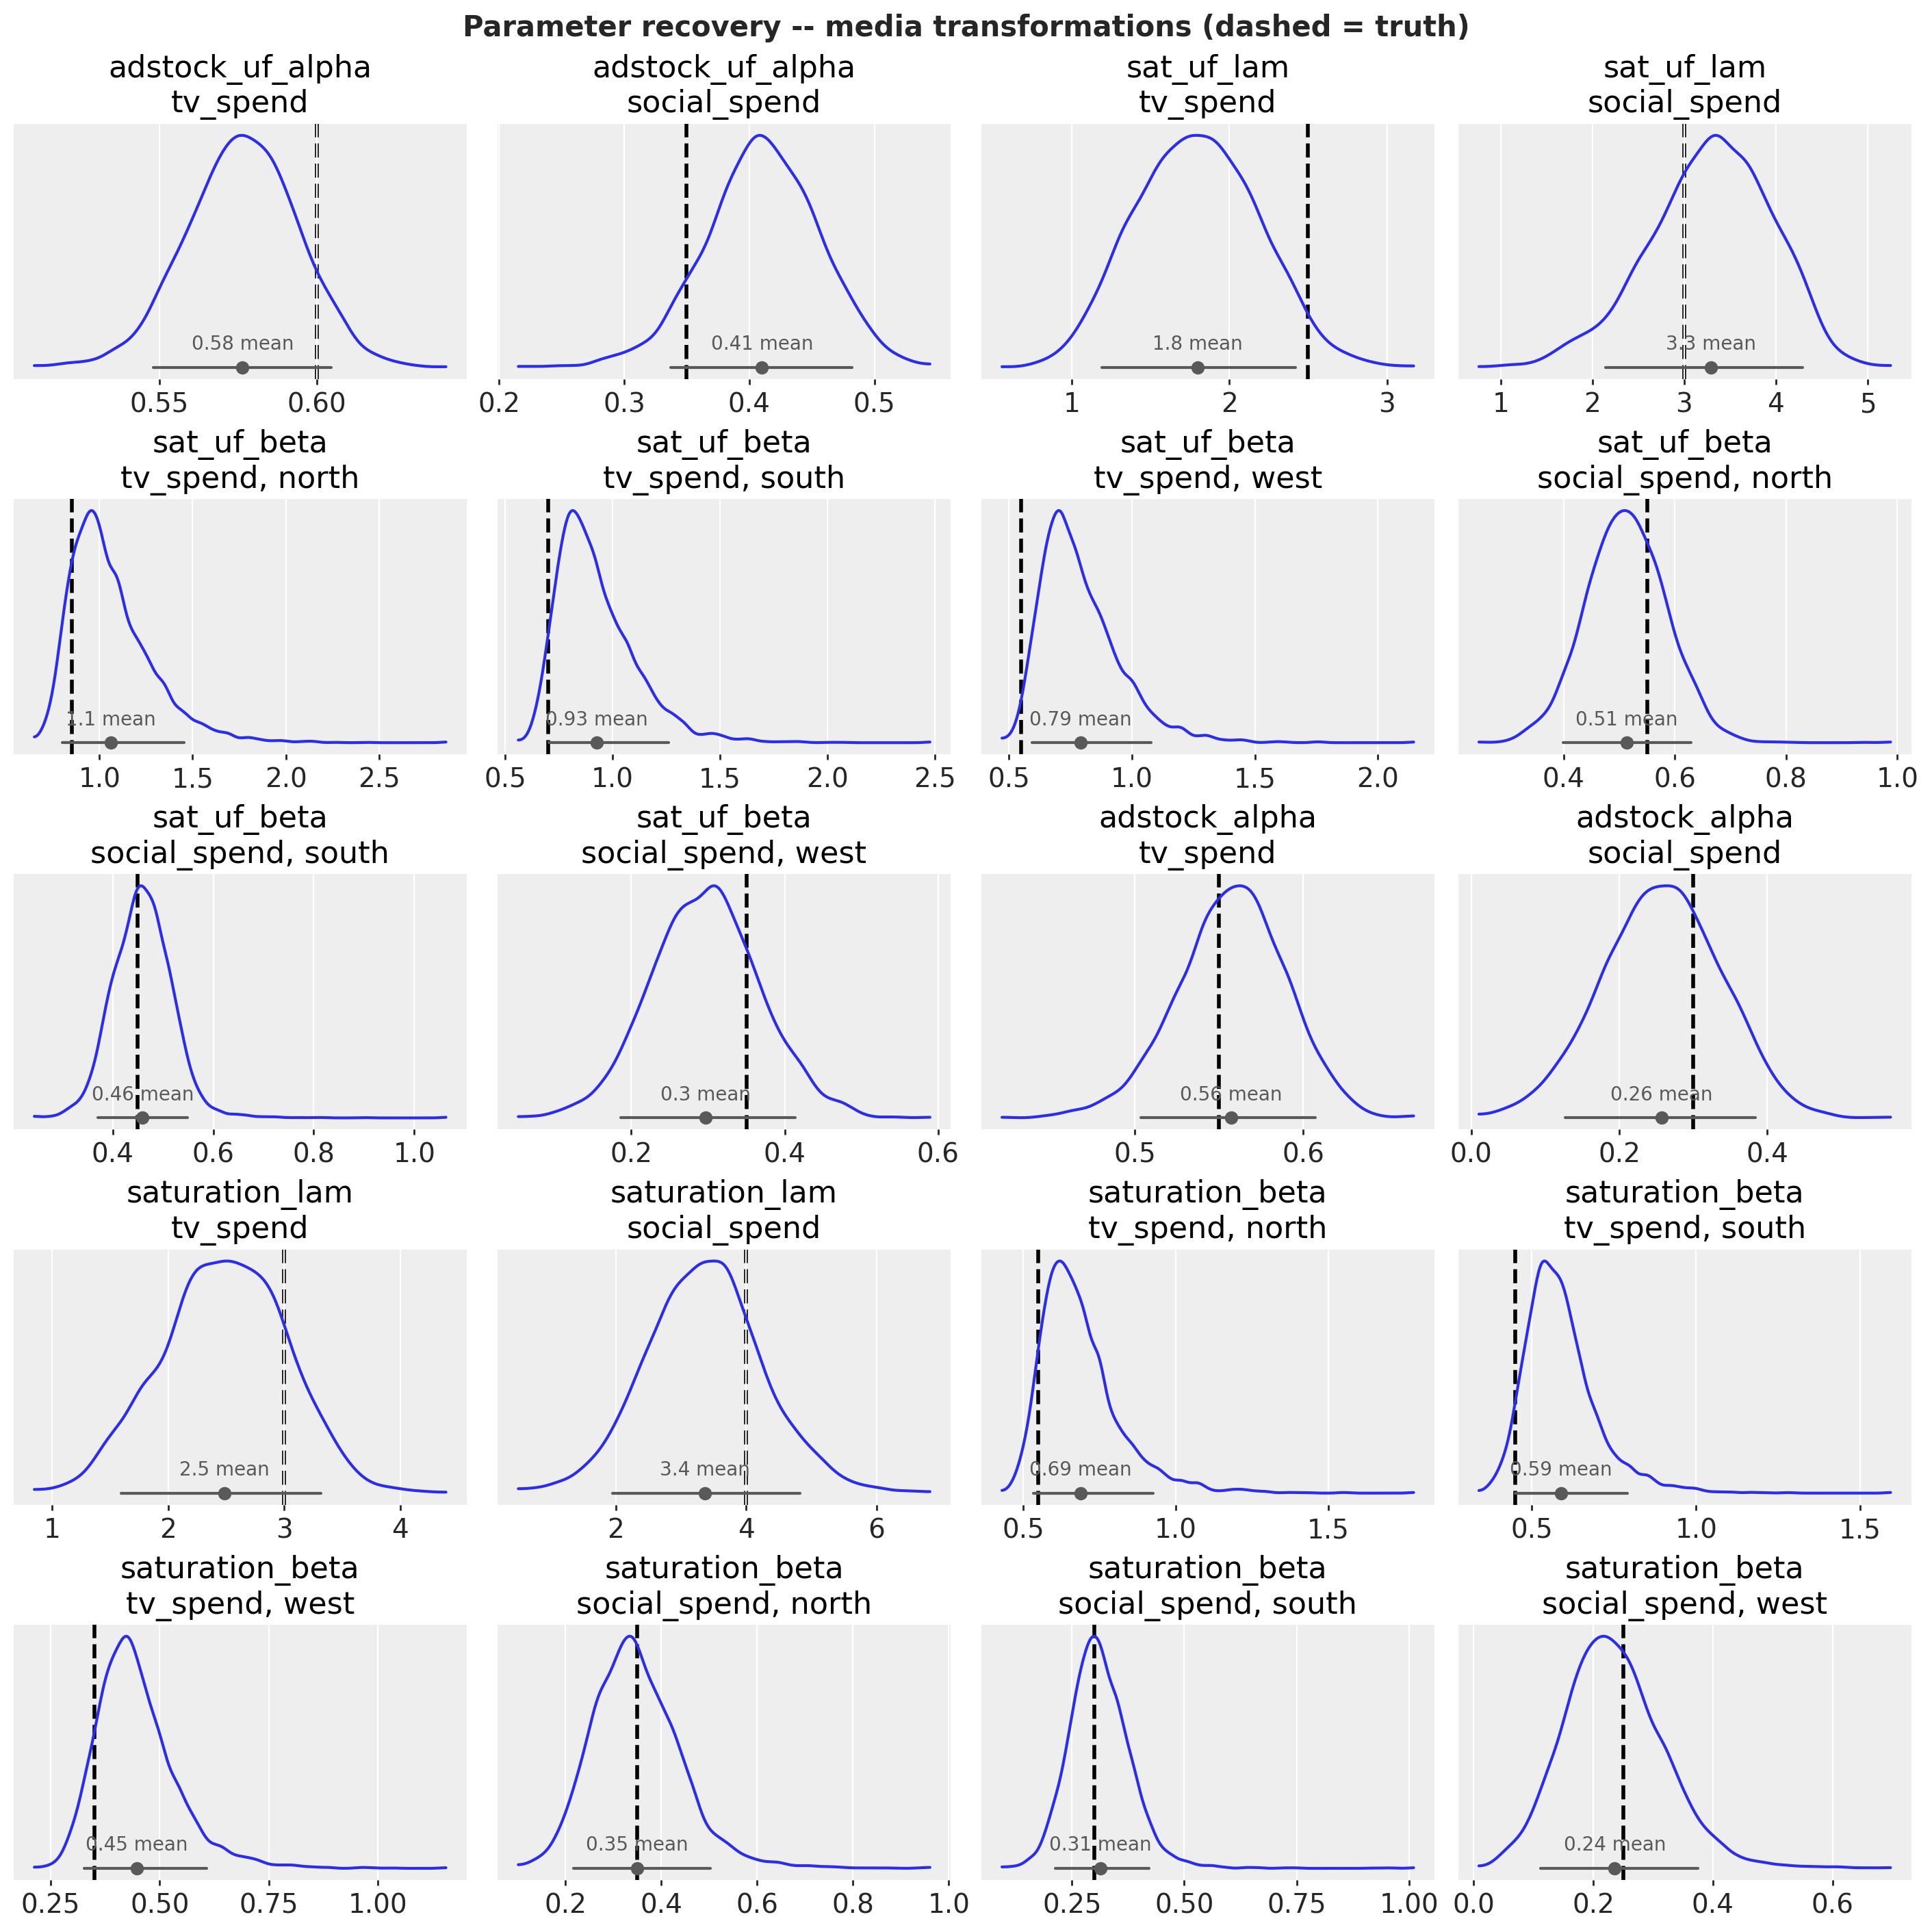

In [31]:
recovery_plot(
    [
        "adstock_uf_alpha",
        "sat_uf_lam",
        "sat_uf_beta",
        "adstock_alpha",
        "saturation_lam",
        "saturation_beta",
    ],
    "Parameter recovery -- media transformations (dashed = truth)",
    (14, 14),
);

These are looser, and for a reason worth naming. The **saturation amplitudes**
(`saturation_beta`, `sat_uf_beta`) sit somewhat above their true values while the
**curvatures** (`saturation_lam`, `sat_uf_lam`) sit below: both the direct and the
indirect path originate at the same upper-funnel spend, so how much of the response
belongs to each is only weakly identified parameter by parameter. `funnel_gamma`
likewise runs a little high -- the flip side of the confounding we built in, since a
seasonal category index and seasonally-planned media are partly interchangeable
explanations for seasonal demand.

As in the basic notebook, what matters for a decision is the **total** effect, and
that survives these trade-offs largely intact, as we see next.

## Direct, indirect, and total effect per channel

We now reconstruct each channel's estimated decomposition. The direct path is the
base channel contribution. The indirect path is the mediated contribution
**minus** what it would be with that channel's spend set to zero -- the same
counterfactual we ran on the generative model, now on the posterior.

In [32]:
def counterfactual_indirect(channel: str) -> xr.DataArray:
    """Posterior mediated contribution attributable to ``channel``."""
    X_zero = X_upper.copy()
    X_zero[channel] = 0.0
    cf = funnel.sample_posterior_predictive(
        X_zero,
        extend_idata=False,
        combined=False,
        var_names=["funnel_effect_contribution_original_scale"],
        random_seed=rng,
    )
    factual = funnel.idata.posterior["funnel_effect_contribution_original_scale"]
    counterfactual = cf["funnel_effect_contribution_original_scale"]
    # Guard the plumbing: when X is a DataFrame the conversion keeps only the channel
    # columns, so the effect's own data variables (including lf_budget) correctly
    # retain their training values. If that ever stopped holding, the mediated
    # contribution would not move and the indirect effect would silently read zero.
    if float(counterfactual.mean()) >= float(factual.mean()):
        raise RuntimeError(
            f"zeroing {channel} did not reduce the mediated contribution -- "
            "the effect's data variables were probably overwritten"
        )
    return factual - counterfactual


direct_post = funnel.idata.posterior["channel_contribution_original_scale"]
indirect_post = xr.concat(
    [counterfactual_indirect(channel) for channel in channels],
    dim=pd.Index(channels, name="channel"),
)
total_post = direct_post + indirect_post

Sampling: []


Output()

Sampling: []


Output()

min component: 0.021753629431118787


/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_79659/198638106.py:53: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.9))


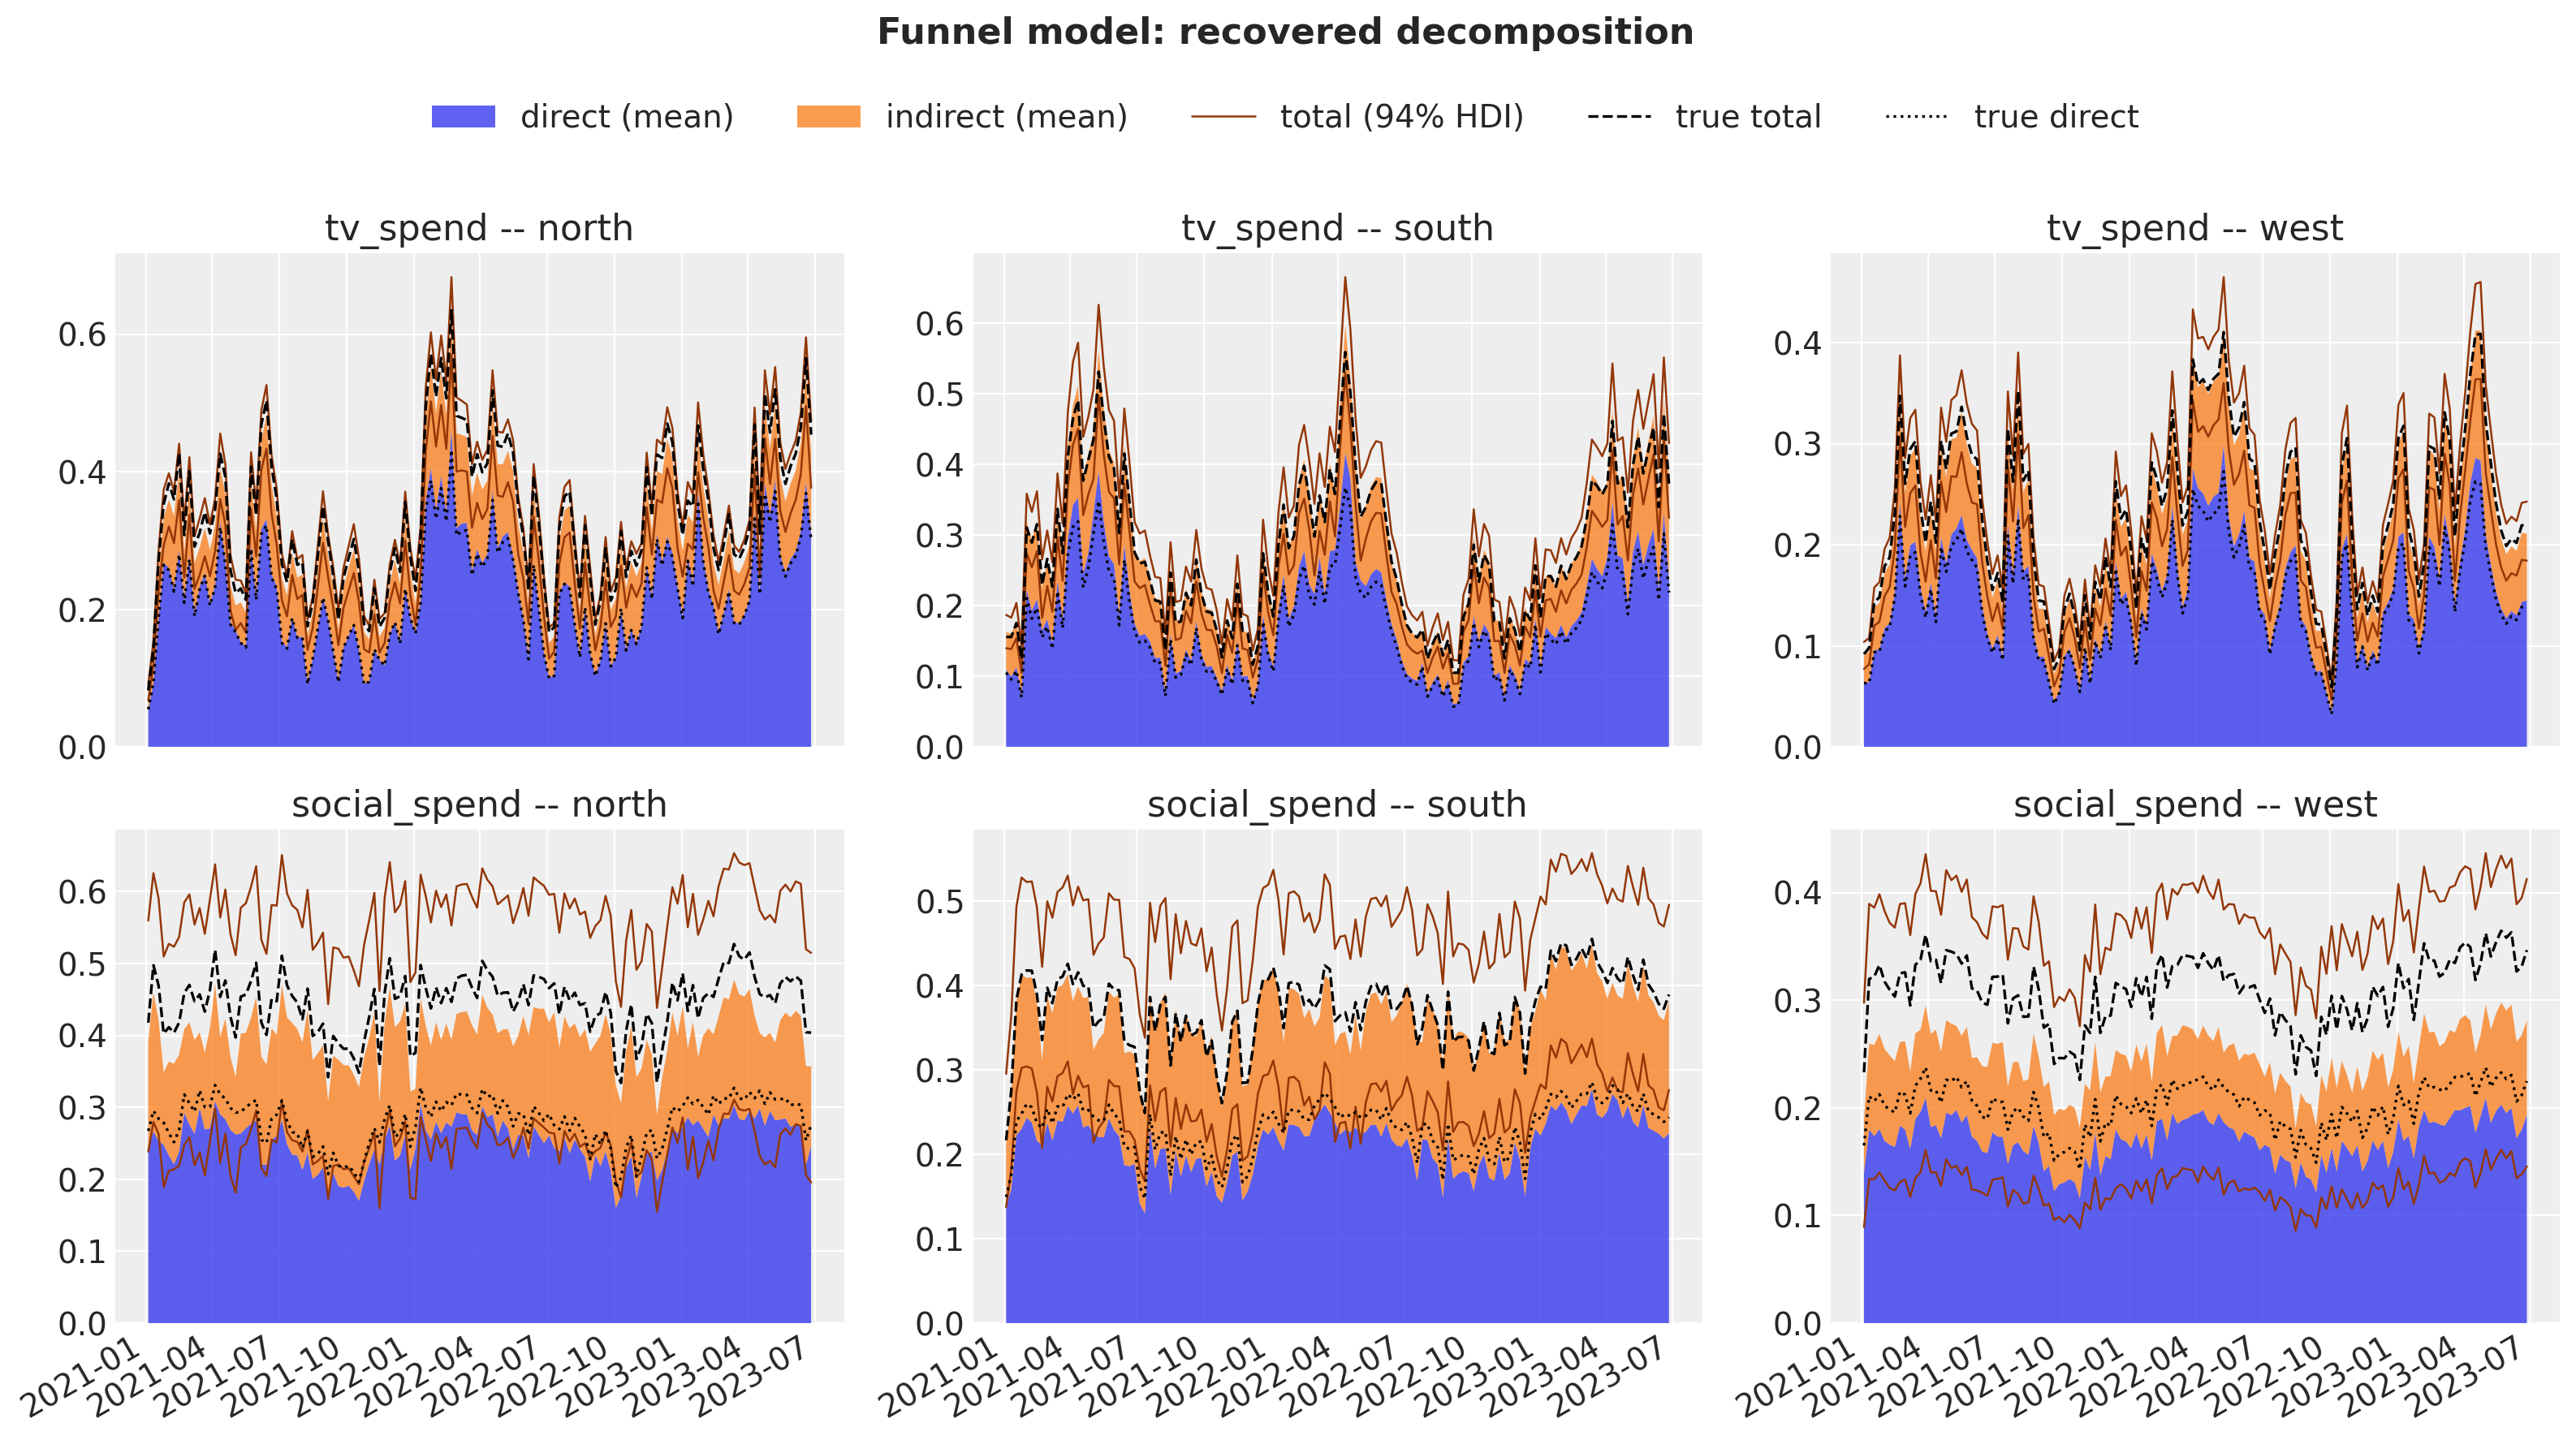

In [33]:
# Direct and indirect are stacked rather than overlaid: three overlapping HDI bands
# are unreadable, and stacking makes `direct + indirect = total` visible directly --
# the top edge of the stack *is* the total.
direct_mean = direct_post.mean(dim=["chain", "draw"])
indirect_mean = indirect_post.mean(dim=["chain", "draw"])
# `stackplot` does not complain about negative values, it just silently draws
# overlapping polygons whose top edge is no longer the total. Both components are
# non-negative here (monotone saturation, non-negative adstock weights), but check.
print("min component:", float(min(direct_mean.min(), indirect_mean.min())))

fig, axes = plt.subplots(
    nrows=len(channels), ncols=len(geos), figsize=(16, 9), sharex=True
)
for row, channel in enumerate(channels):
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        sel = {"channel": channel, "geo": geo}
        ax.stackplot(
            date_range,
            direct_mean.sel(sel),
            indirect_mean.sel(sel),
            labels=["direct (mean)", "indirect (mean)"],
            colors=["C0", "C1"],
            alpha=0.75,
        )
        # The total's uncertainty is drawn as bounding lines rather than a filled
        # band: a translucent fill over the stack tints both components and makes
        # the decomposition harder to read, not easier.
        lo, hi = hdi_bounds(total_post.sel(sel))
        ax.plot(date_range, lo, color="C4", lw=0.9, label="total (94% HDI)")
        ax.plot(date_range, hi, color="C4", lw=0.9)
        ax.plot(
            date_range,
            data["total_true"].sel(sel),
            color="black",
            linestyle="--",
            lw=1.2,
            label="true total",
        )
        ax.plot(
            date_range,
            data["direct_true"].sel(sel),
            color="black",
            linestyle=":",
            lw=1.2,
            label="true direct",
        )
        ax.set_title(f"{channel} -- {geo}")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncols=5)
fig.suptitle("Funnel model: recovered decomposition", fontsize=16, fontweight="bold")
fig.autofmt_xdate()
fig.tight_layout(rect=(0, 0, 1, 0.9))

The stack edge is a posterior *mean* while the band is an HDI, so the two need not
be concentric. The point of the figure is the split: how much of each channel's
contribution travels directly versus through lower-funnel spend, against the two
black reference lines.

## Head-to-head: the bias from ignoring the funnel

Finally we compare the four models on the quantity a budget decision actually
turns on -- the **total contribution of each upper-funnel channel**. For the naive
models the channel contribution is already the counterfactual versus zero spend.
For the funnel model we use direct plus the counterfactual indirect effect.

In [34]:
def total_contribution(model: MMM, channel: str) -> xr.DataArray:
    """Mean-over-time total contribution of ``channel`` for a naive model."""
    return (
        model.idata.posterior["channel_contribution_original_scale"]
        .sel(channel=channel)
        .mean(dim="date")
    )


estimates = {
    "Naive A (mediator as channel)": lambda ch: total_contribution(naive_a, ch),
    "Naive B (mediator omitted)": lambda ch: total_contribution(naive_b, ch),
    "Naive C (indicator as channel)": lambda ch: total_contribution(naive_c, ch),
    "Funnel": lambda ch: total_post.sel(channel=ch).mean(dim="date"),
}

truth_mean = data["total_true"].mean("date")
direct_truth_mean = data["direct_true"].mean("date")

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_79659/2131523870.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.9))


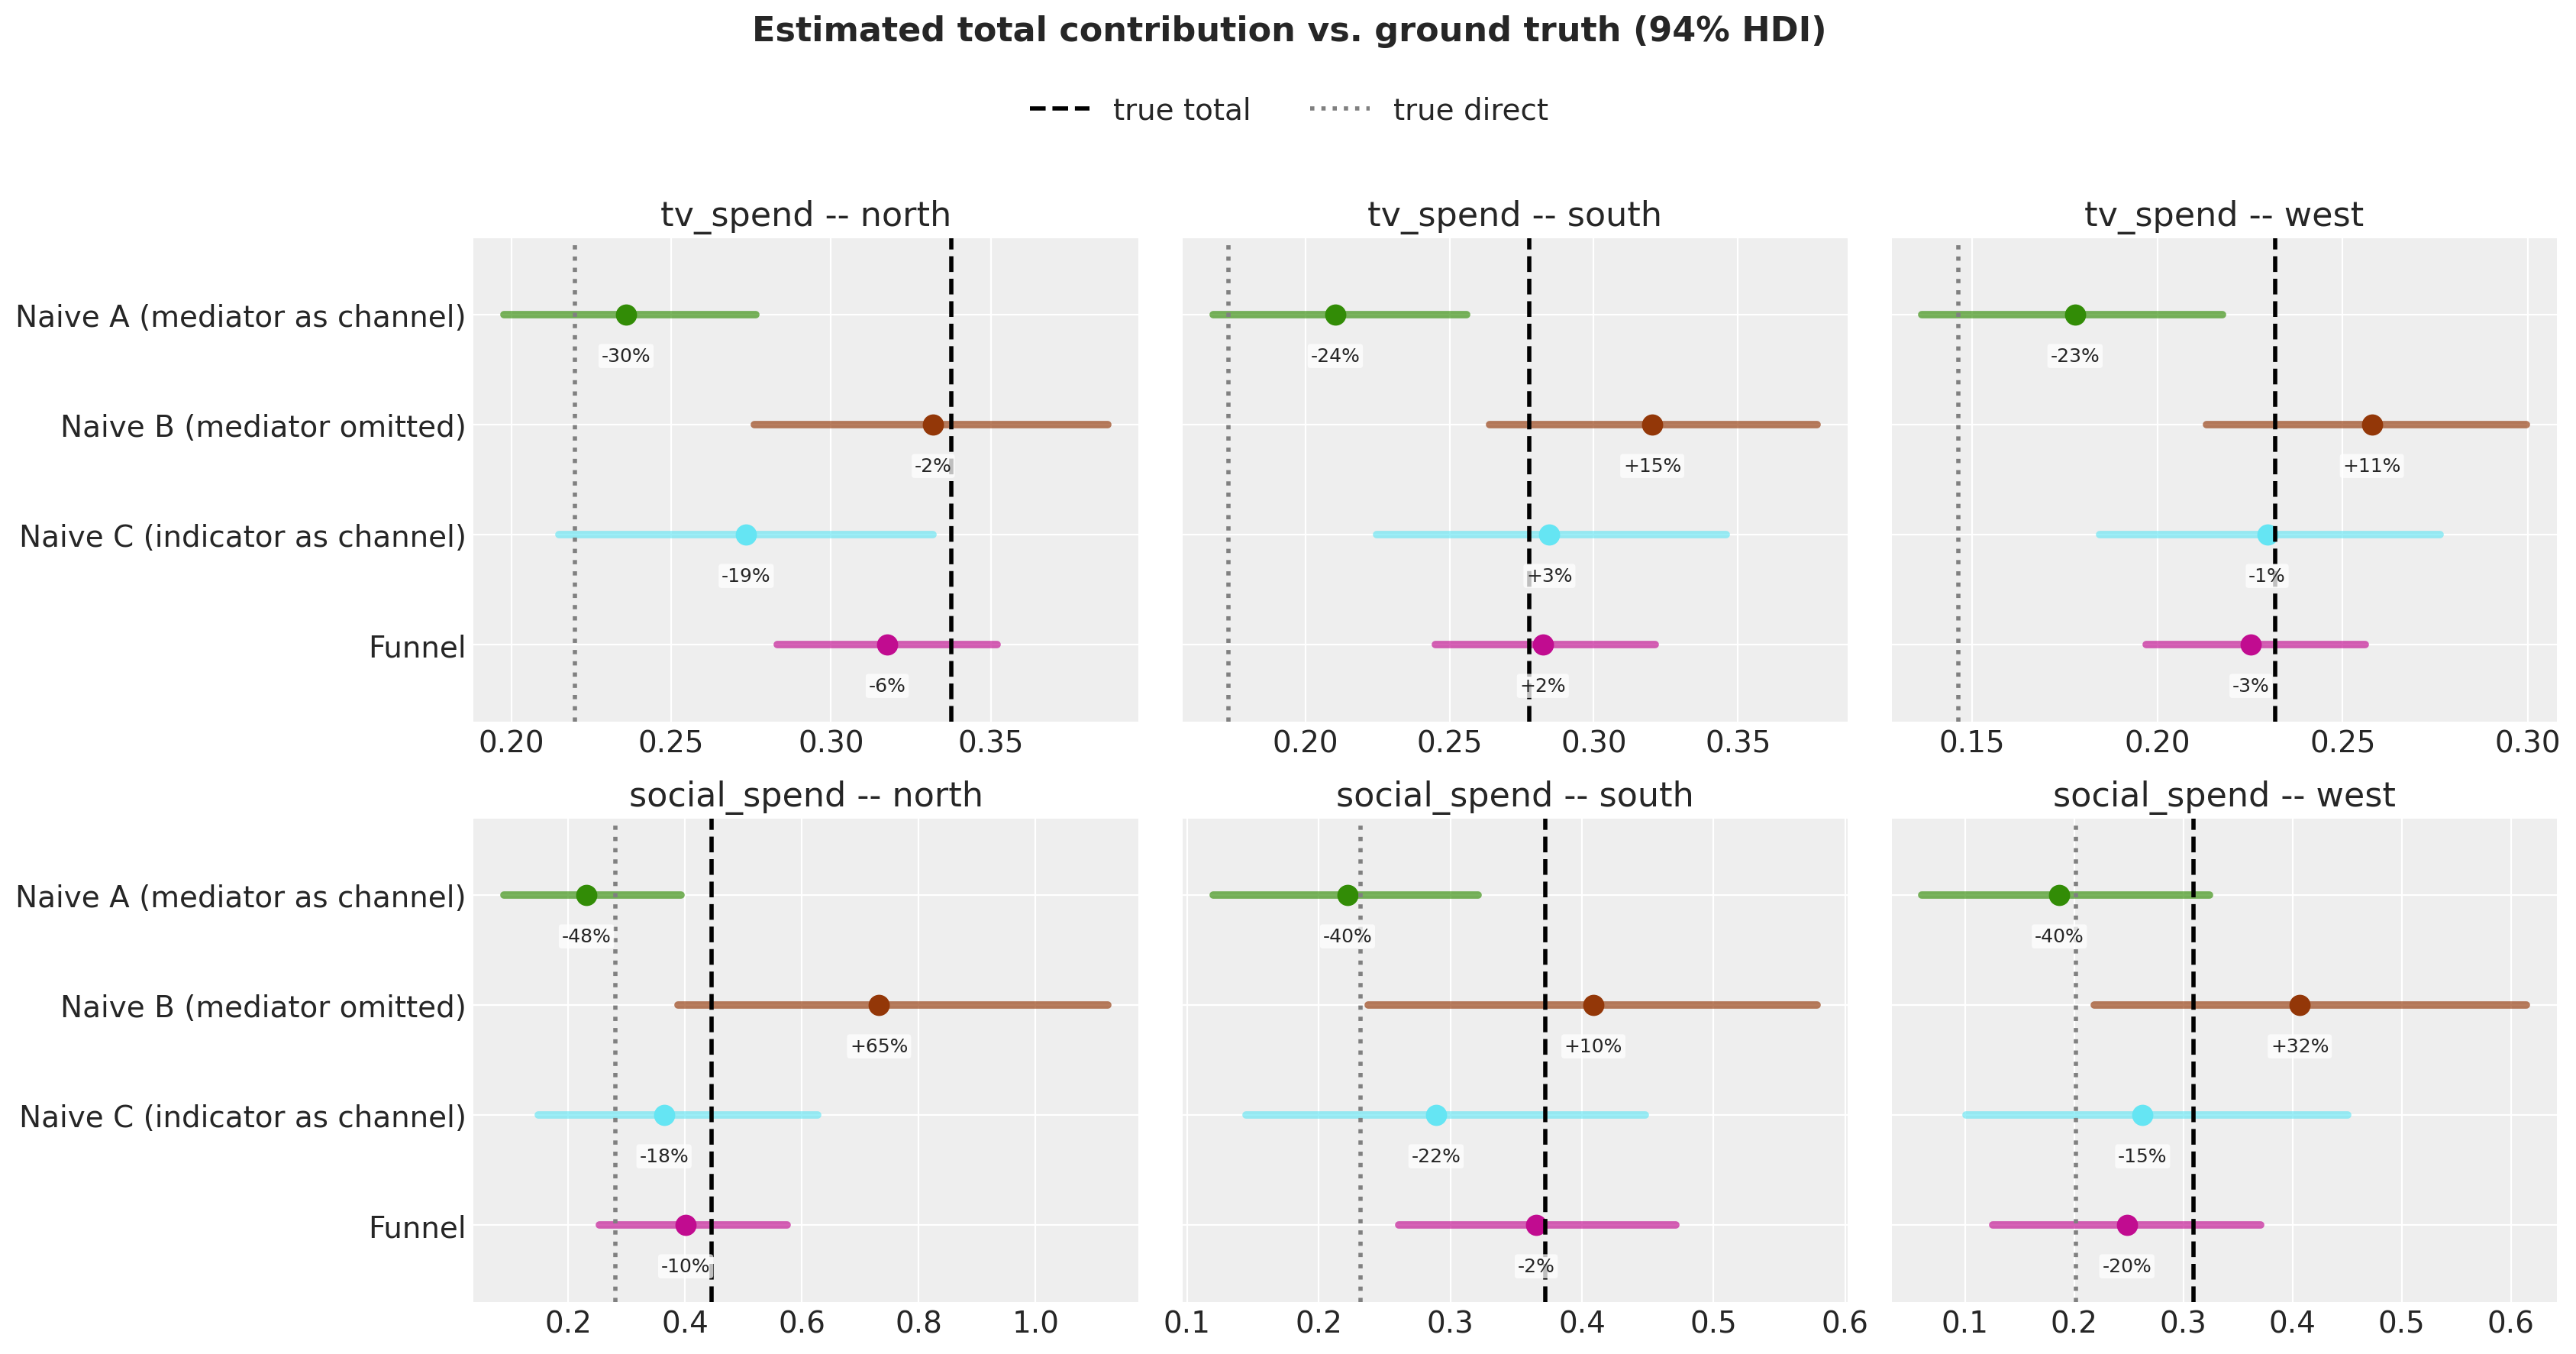

In [35]:
fig, axes = plt.subplots(nrows=len(channels), ncols=len(geos), figsize=(17, 9))
for row, channel in enumerate(channels):
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        sel = {"channel": channel, "geo": geo}
        forest_panel(
            ax,
            {label: est(channel).sel(geo=geo) for label, est in estimates.items()},
            reference={
                "total": (float(truth_mean.sel(sel)), TRUE_STYLE["total"]),
                "direct": (float(direct_truth_mean.sel(sel)), TRUE_STYLE["direct"]),
            },
        )
        ax.set_title(f"{channel} -- {geo}")
        ax.tick_params(labelleft=col == 0)
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncols=2)
fig.suptitle(
    "Estimated total contribution vs. ground truth (94% HDI)",
    fontsize=16,
    fontweight="bold",
)
fig.tight_layout(rect=(0, 0, 1, 0.9))

Three different failure modes, and only one of them looks like a simple shift.

**Naive A understates every upper-funnel channel, everywhere.** Putting the
mediator in as a channel conditions on it, which blocks the indirect path by
construction. Note that the model is not *wrong* about lower-funnel spend -- that
spend really does convert -- it is wrong about who gets the credit for causing it.
This bias is systematic and its direction is predictable.

**Naive B overstates, and the overstatement is channel-specific.** Omitting the
mediator leaves the seasonal, category-driven part of lower-funnel demand
unexplained, and the model hands it to whichever channel correlates with it. Social
spend -- which tracks category demand closely -- is badly overstated, while TV,
which is nearly orthogonal to it, comes out close to unbiased in the largest geo.

**Naive C fails the same way as A, but for a subtler reason and only in some
cells.** Branded search is a near-perfect proxy for latent demand, so conditioning
on it blocks the mediated path just as conditioning on the mediator would. The
damage concentrates on social spend, whose plan follows demand, and on the largest
geo; TV in the two smaller geos comes out near-unbiased. The picture a practitioner
would actually see is a model that looks fine in several cells and quietly
understates in the rest -- arguably more dangerous than a uniformly wrong one.

That asymmetry is the uncomfortable part in practice. None of these biases is a
uniform shift you could correct with a fudge factor. Each concentrates on the
channels whose plans follow demand, which are often exactly the ones under
scrutiny.

The funnel model tracks the truth most closely overall, but not in literally every
cell -- a naive model occasionally lands closer by coincidence, where two biases
offset. We quantify that properly below, where a single number per model replaces
eyeballing eighteen intervals.

## ROAS, nationally and per geo

Budget decisions key off return on ad spend, so let us express the same comparison
that way. All four estimates use the **same** definition -- contribution summed over
the observed weeks, divided by spend over those same weeks -- so that any difference
between them is structural rather than definitional.

In [36]:
spend = data[channels].to_array("channel").sum("date")


def roas_from(contribution: xr.DataArray) -> xr.DataArray:
    """All-time ROAS: summed contribution over summed spend, per channel and geo."""
    return contribution.sel(channel=channels).sum(dim="date") / spend


def direct_roas(model: MMM) -> xr.DataArray:
    """Direct-path ROAS from a model's own channel contributions."""
    return roas_from(model.idata.posterior["channel_contribution_original_scale"])


roas = {
    "Naive A (mediator as channel)": direct_roas(naive_a),
    "Naive B (mediator omitted)": direct_roas(naive_b),
    "Naive C (indicator as channel)": direct_roas(naive_c),
    "Funnel (total)": roas_from(total_post),
    "Funnel (direct only)": roas_from(direct_post),
}

true_total_roas = data["total_true"].sum("date") / spend
true_direct_roas = data["direct_true"].sum("date") / spend

```{note}
`mmm.incrementality.contribution_over_spend(frequency="all_time")` computes the
same quantity with one difference: it defaults to `include_carryover=True`, which
extends the evaluation window by `l_max` weeks past the data to capture adstock
still in flight. That is usually what you want; here we need every row on an
identical window, so we compute it directly. The two agree closely -- and note that
the built-in only sees `channel_contribution`, so for the funnel model it returns
the **direct** path and misses the mediated one entirely.
```

In [37]:
builtin_direct = funnel.incrementality.contribution_over_spend(
    frequency="all_time"
).sel(channel=channels)

pd.DataFrame(
    {
        "manual (in-sample window)": roas["Funnel (direct only)"]
        .mean(dim=["chain", "draw"])
        .transpose("channel", "geo")
        .to_series(),
        "incrementality (with carryover)": builtin_direct.mean(dim=["chain", "draw"])
        .transpose("channel", "geo")
        .to_series(),
    }
).style.format("{:.4f}")

### Nationally

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_79659/1820603136.py:25: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


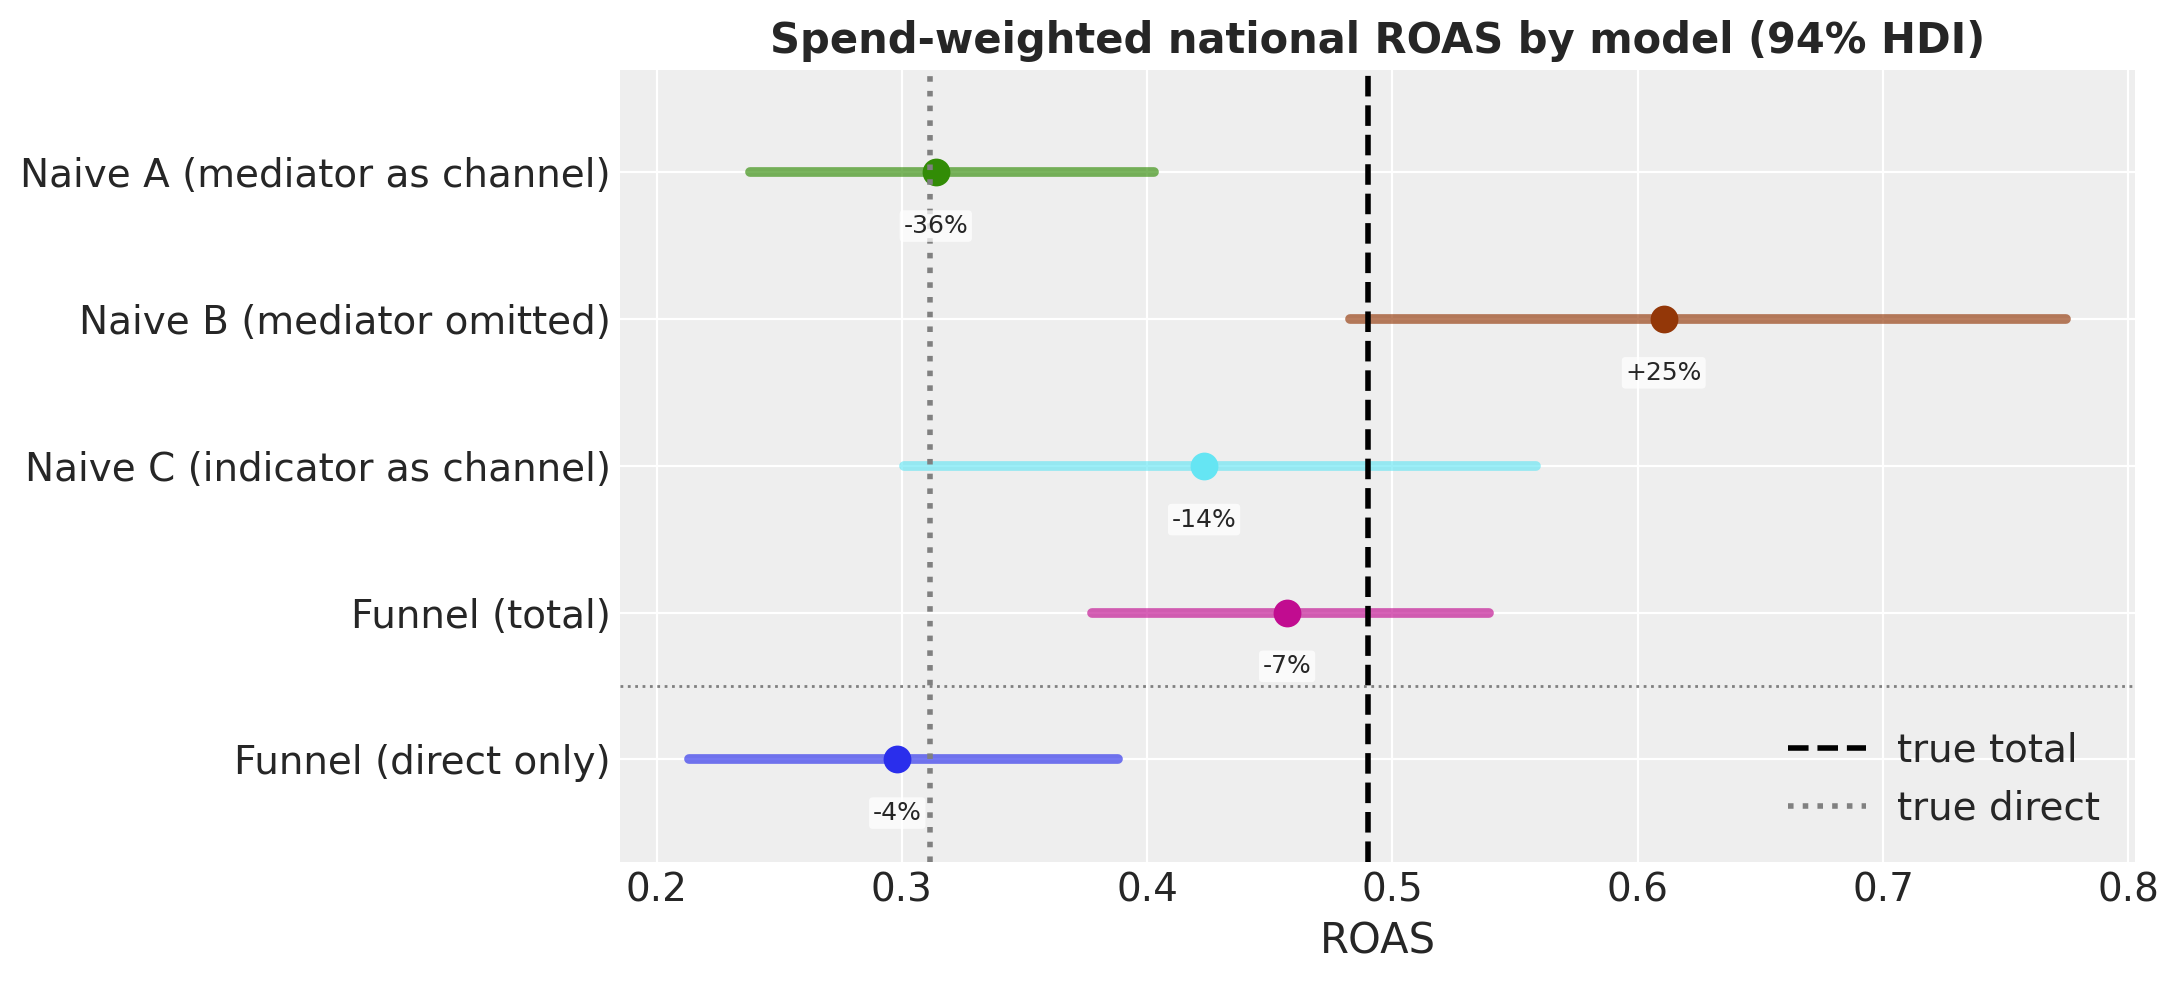

In [38]:
national = {
    label: (da * spend).sum("channel").sum("geo") / spend.sum()
    for label, da in roas.items()
}
national_true_total = float((true_total_roas * spend).sum() / spend.sum())
national_true_direct = float((true_direct_roas * spend).sum() / spend.sum())

fig, ax = plt.subplots(figsize=(11, 5))
forest_panel(
    ax,
    national,
    reference={
        "total": (national_true_total, TRUE_STYLE["total"]),
        "direct": (national_true_direct, TRUE_STYLE["direct"]),
    },
)
ax.axhline(len(national) - 1.5, color="gray", linestyle=":", lw=1)
ax.set_xlabel("ROAS")
ax.legend(loc="lower right")
ax.set_title(
    "Spend-weighted national ROAS by model (94% HDI)",
    fontsize=15,
    fontweight="bold",
)
fig.tight_layout()

The first four rows all estimate the **total** effect and are annotated against the
true total (dashed black). The last row is separated because it estimates something
different -- the funnel model's *direct* path only -- and is annotated against the
true direct ROAS (dotted grey). It should sit on the dotted line, and does.

Read as a budget input: the three naive models disagree with the truth in three
different directions, and nothing in the models themselves tells you which one you
are looking at.

### Per geo and channel

The national number averages over exactly the heterogeneity a geo panel exists to
expose, so it is worth breaking out. `contribution_over_spend` and our manual
version both return `(chain, draw, channel, geo)`, so no extra computation is
needed -- only a different view of it.

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_79659/2187212586.py:25: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.9))


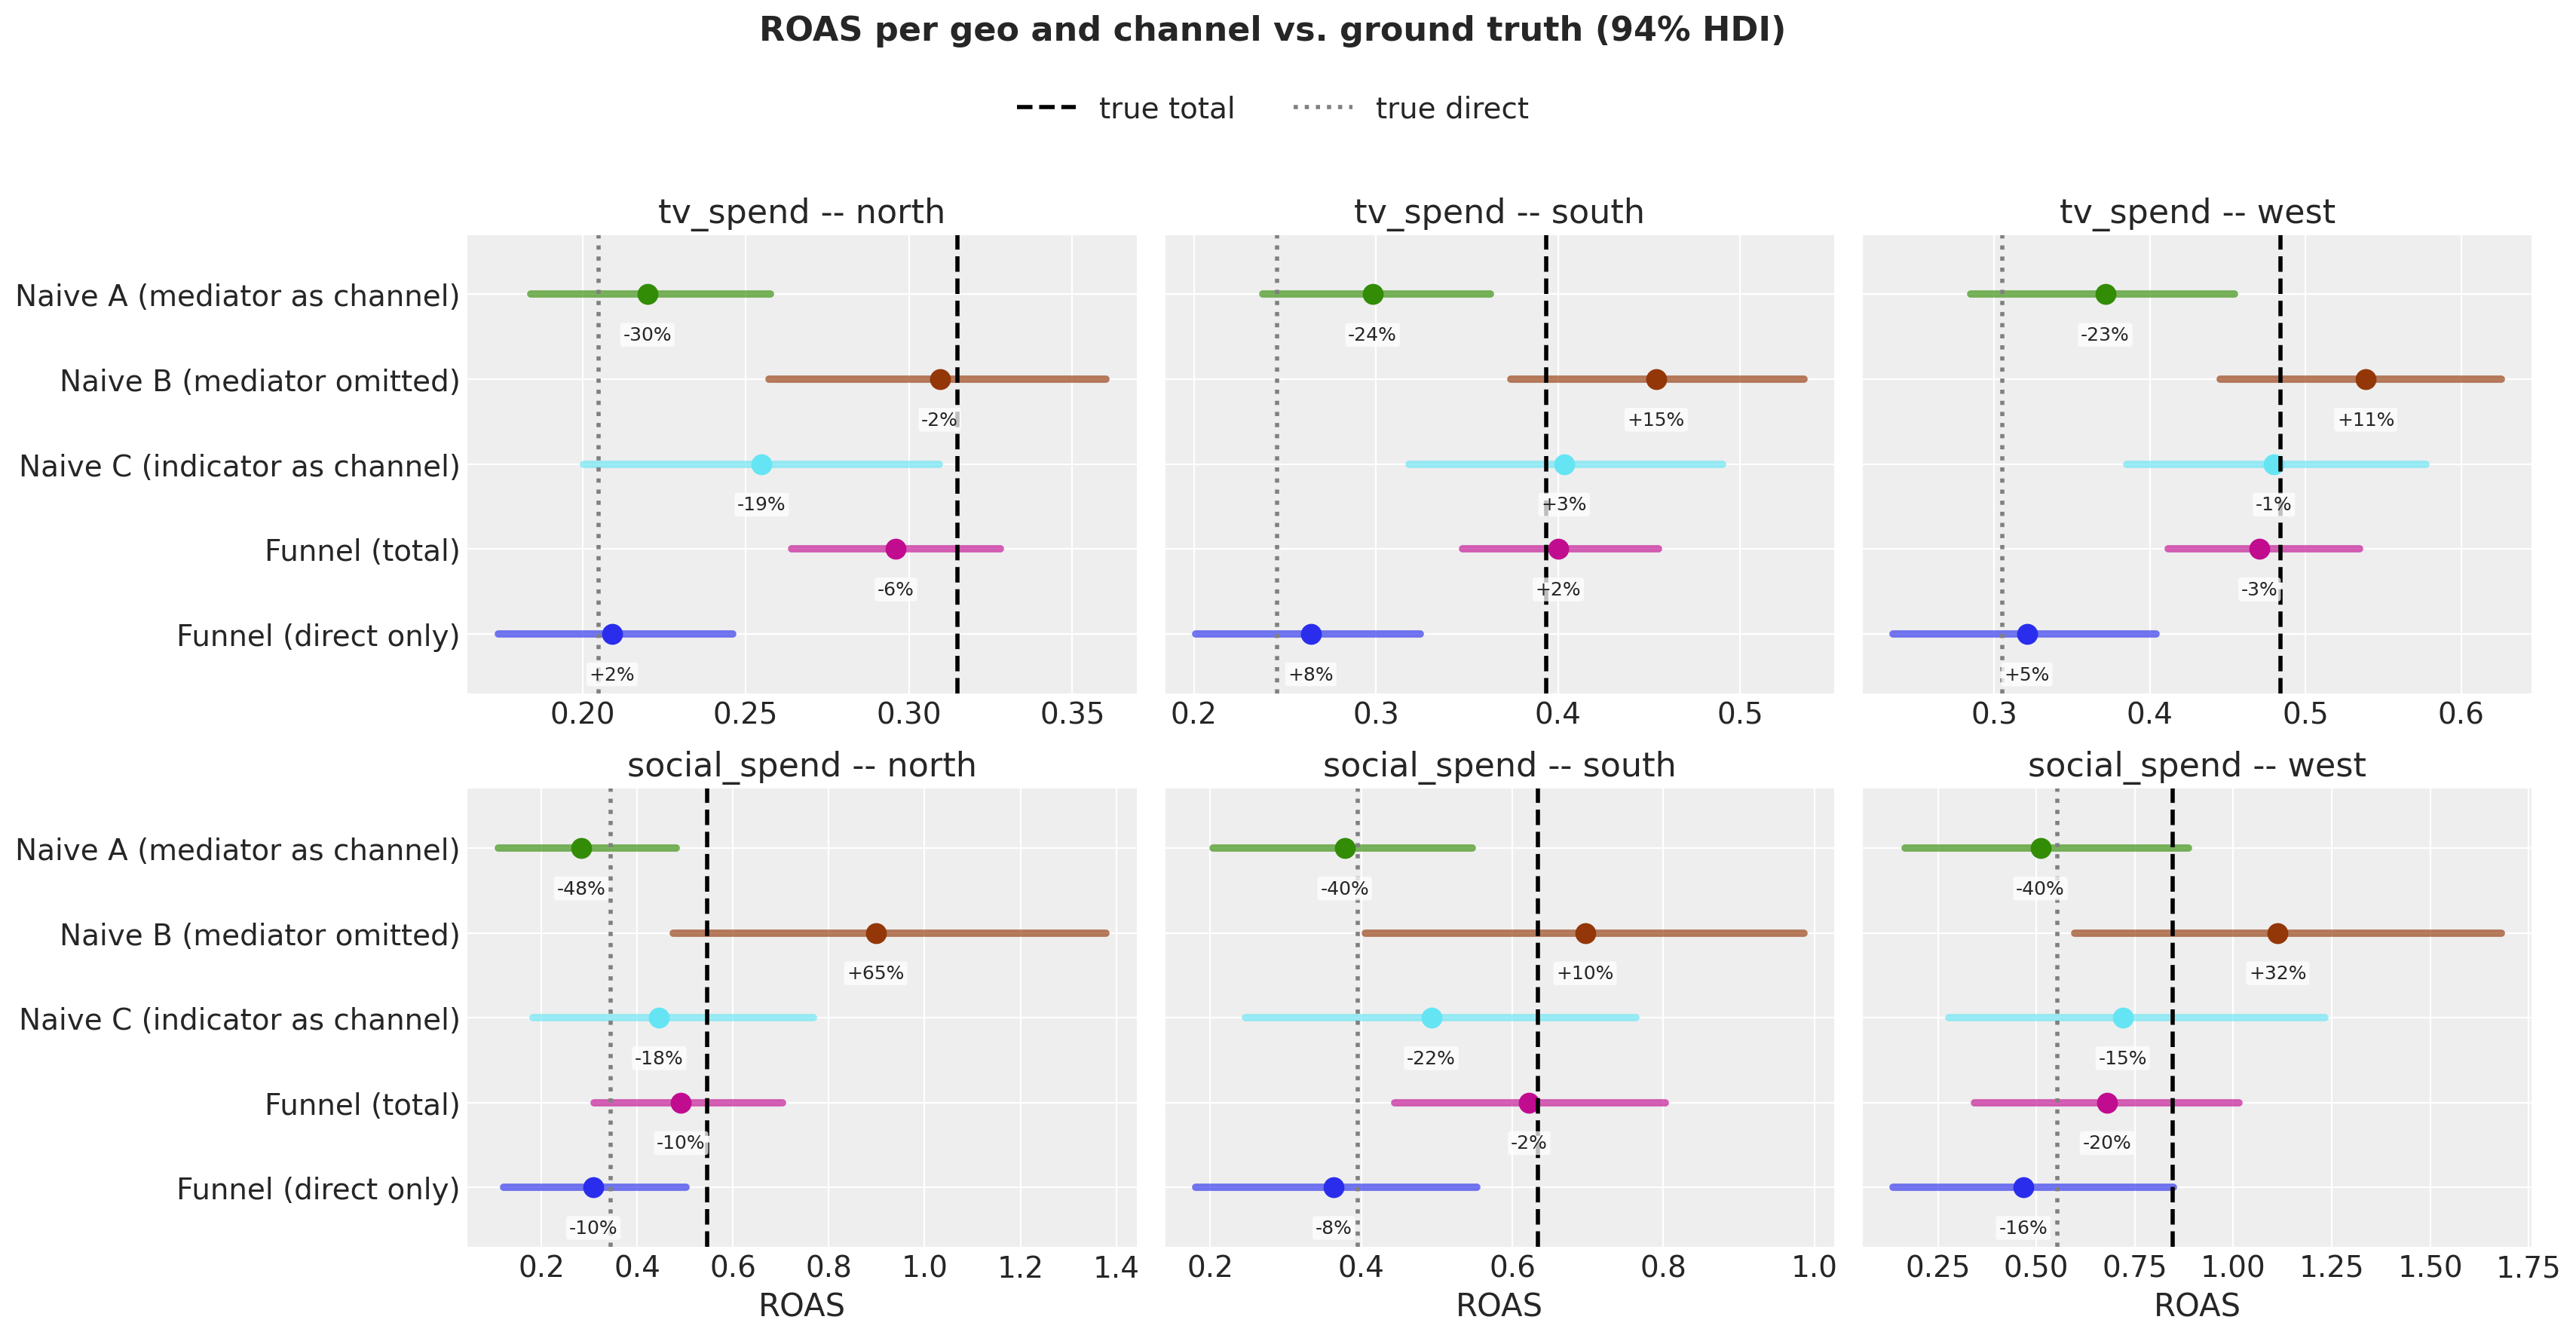

In [39]:
fig, axes = plt.subplots(nrows=len(channels), ncols=len(geos), figsize=(17, 9))
for row, channel in enumerate(channels):
    for col, geo in enumerate(geos):
        ax = axes[row, col]
        sel = {"channel": channel, "geo": geo}
        forest_panel(
            ax,
            {label: da.sel(sel) for label, da in roas.items()},
            reference={
                "total": (float(true_total_roas.sel(sel)), TRUE_STYLE["total"]),
                "direct": (float(true_direct_roas.sel(sel)), TRUE_STYLE["direct"]),
            },
        )
        ax.set_title(f"{channel} -- {geo}")
        ax.tick_params(labelleft=col == 0)
        if row == len(channels) - 1:
            ax.set_xlabel("ROAS")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), ncols=2)
fig.suptitle(
    "ROAS per geo and channel vs. ground truth (94% HDI)",
    fontsize=16,
    fontweight="bold",
)
fig.tight_layout(rect=(0, 0, 1, 0.9))

The same comparison as a table of levels, then as bias against the true total:

In [40]:
roas_summary = pd.DataFrame(
    {
        label: da.mean(dim=["chain", "draw"]).transpose("channel", "geo").to_series()
        for label, da in roas.items()
    }
)
roas_summary["true direct"] = true_direct_roas.transpose("channel", "geo").to_series()
roas_summary["true total"] = true_total_roas.transpose("channel", "geo").to_series()
roas_summary.style.format("{:.3f}")

In [41]:
total_estimates = [
    "Naive A (mediator as channel)",
    "Naive B (mediator omitted)",
    "Naive C (indicator as channel)",
    "Funnel (total)",
]
bias = roas_summary[total_estimates].div(roas_summary["true total"], axis=0) - 1
bias.loc[("mean |error|", "")] = bias.abs().mean()
bias.style.background_gradient(
    cmap="RdBu_r", vmin=-0.5, vmax=0.5, subset=pd.IndexSlice[channels, :]
).format("{:+.1%}")

A point estimate being off is one thing; being *confidently* off is worse. The
table below asks, for every geo and channel, whether each model's 94% HDI actually
contains the true total ROAS -- and how wide that interval had to be.

In [42]:
rows = []
for c in channels:
    for g in geos:
        truth = float(true_total_roas.sel(channel=c, geo=g))
        row = {}
        for label in total_estimates:
            lo, hi = hdi_bounds(roas[label].sel(channel=c, geo=g))
            row[(label, "covers")] = bool(float(lo) <= truth <= float(hi))
            row[(label, "width")] = float(hi) - float(lo)
        rows.append(row)

coverage = pd.DataFrame(
    rows, index=pd.MultiIndex.from_product([channels, geos], names=["channel", "geo"])
)
coverage.columns = pd.MultiIndex.from_tuples(coverage.columns)

for label in total_estimates:
    n = int(coverage[(label, "covers")].sum())
    width = coverage[(label, "width")].mean()
    print(f"{label:32s} covers {n}/6   mean HDI width {width:.3f}")

coverage.style.format({(m, "width"): "{:.3f}" for m in total_estimates}).map(
    lambda v: (
        f"background-color: {'#c8e6c9' if v else '#ffcdd2'}"
        if isinstance(v, bool)
        else ""
    )
)

Naive A (mediator as channel)    covers 1/6   mean HDI width 0.300
Naive B (mediator omitted)       covers 6/6   mean HDI width 0.502
Naive C (indicator as channel)   covers 5/6   mean HDI width 0.422
Funnel (total)                   covers 6/6   mean HDI width 0.287


Read the two tables together, because separately each one misleads.

**Naive A is confidently wrong.** It understates every cell, by 23% to 48%, and its
intervals are tight enough to exclude the truth almost everywhere. This is the
worst combination: a precise answer pointing the wrong way.

**Naive B is not so much wrong as uninformative.** It covers every cell -- but only
because its intervals are by far the widest of the four. With the mediator omitted,
the upper-funnel response curves have to absorb seasonal demand as well as their
own effect, and the posterior widens to accommodate both stories. An interval wide
enough to contain a +65% error is not evidence of a good model.

**Naive C sits in between**, understating by 15%-22% wherever the channel's plan
follows demand and coming out near-unbiased on TV in the two smaller geos.

**The funnel model has the smallest mean error and full coverage.** It is not
uniformly best cell by cell -- `Naive C` happens to land closer on `tv_spend` in
`west`, and `Naive B` on `tv_spend` in `north` -- but those are the cells where an
omitted path and a confounded one happen to cancel. Averaged over the panel its
error is roughly half the next best model's, and unlike the naive models it is
never badly wrong anywhere.

### The bias barely shows up in predictive fit

Here is the punchline, and it survives the move to a geo panel. If we ranked these
models by how well they fit the target, they would be separated by well under one
point of $R^2$ -- while their ROAS conclusions differ by tens of percent. A gap that
small is comfortably inside the range you would shrug off as noise between two
reasonable specifications. The causal bias simply does not express itself as
predictive error, which is why held-out fit alone cannot catch it.

In [43]:
r2 = {}
for label, model in models.items():
    pp = (
        model.idata.posterior_predictive["y"]
        * model.idata.constant_data["target_scale"]
    )
    y_hat = pp.mean(dim=["chain", "draw"])
    y_true, y_hat = xr.align(data["y"], y_hat, join="exact")
    ss_res = float(((y_true - y_hat) ** 2).sum())
    ss_tot = float(((y_true - y_true.mean()) ** 2).sum())
    r2[label] = 1 - ss_res / ss_tot

pd.Series(r2, name="in-sample $R^2$").to_frame().style.format("{:.4f}")

,in-sample $R^2$
Naive A,0.9848
Naive B,0.9777
Naive C,0.9782
Funnel,0.9862


### What the built-in decomposition shows -- and what it cannot

Everything causal in this notebook was post-processing. It is worth seeing what the
library's own decomposition reports for the same fitted model, because the gap is
the entire point.

`decomposition.contributions_over_time` and `decomposition.waterfall` recognise a
fixed set of components -- channels, baseline, controls, seasonality. A custom
`MuEffect` is none of those.

/Users/juanitorduz/Documents/pymc-marketing/pymc_marketing/mmm/plotting/decomposition.py:394: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


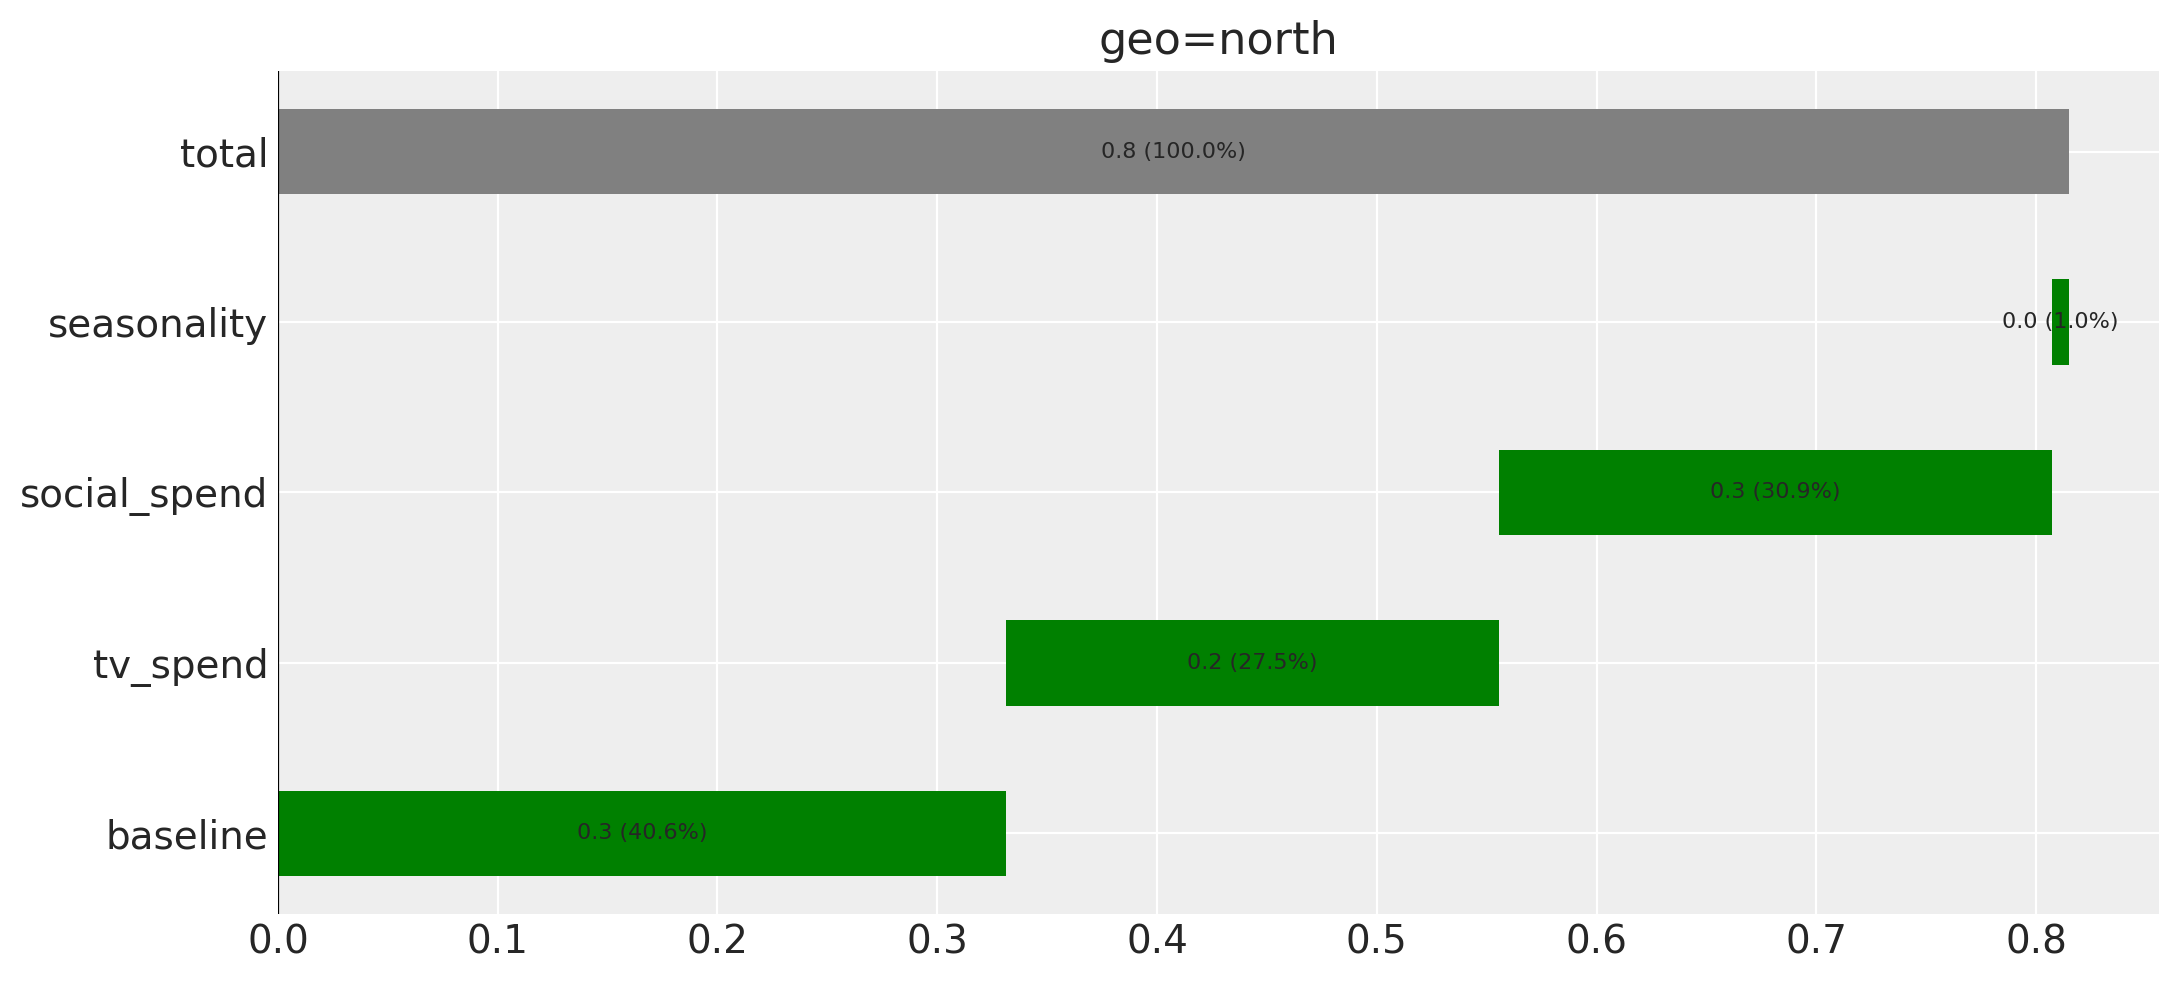

In [44]:
funnel.plot.decomposition.waterfall(dims={"geo": ["north"]}, figsize=(11, 5));

The `channels` bars are the **direct** paths only, and the mediated contribution is
not redistributed into the baseline either -- it is simply absent. The bars do not
add up to the target:

In [45]:
waterfall_total = float(
    (
        funnel.idata.posterior["intercept_contribution"]
        * funnel.idata.constant_data["target_scale"]
        + funnel.idata.posterior["channel_contribution_original_scale"].sum("channel")
    )
    .sel(geo="north")
    .mean()
)
mediated = float(
    funnel.idata.posterior["funnel_effect_contribution_original_scale"]
    .sel(geo="north")
    .mean()
)
print(f"direct + intercept (roughly the waterfall total): {waterfall_total:.2f}")
print(f"mediated contribution, entirely missing from it:  {mediated:.2f}")
print(
    f"observed target mean:                             {float(data['y'].sel(geo='north').mean()):.2f}"
)

direct + intercept (roughly the waterfall total): 0.81
mediated contribution, entirely missing from it:  0.80
observed target mean:                             1.62


Roughly half the target is unaccounted for. A reader taking those bars as an
attribution would under-credit both channels by the mediated amounts we computed
above, and would be missing the largest single component of the model.

This is a boundary to know rather than a bug to route around: the DAG lives in your
`create_effect` code, and only you can tell the library that a particular additive
term means "demand this channel created". Everything causal in this notebook came
from post-processing the posterior, not from a built-in.

## Caveats and extensions

- **The framework does not "see" the DAG.** The funnel structure lives in the
  `FunnelEffect` code. The built-in decomposition recognises a fixed set of
  components, and a custom `MuEffect` is not among them -- as the waterfall above
  shows, the mediated contribution is omitted from it entirely rather than
  reassigned. Anything causal has to come from post-processing, as it did here.
- **Pass a `Dataset`, not a `DataFrame`.** Extra columns in a DataFrame are
  dropped during conversion, so a `DataVarMuEffect` would not find its variables.
  Build the model from an `xarray.Dataset`; `fit` still takes the long frame for
  its bookkeeping.
- **Pooling choices are identification choices.** We pooled carryover and
  curvature across geos and left amplitudes free. Freeing everything per geo with
  ~130 weeks each will widen the posteriors considerably and can introduce
  divergences; hierarchical (partially pooled) priors are the natural next step.
- **Latent variables need an anchor.** Fixing at one the coefficient on $D$ in the
  lower-funnel spend equation is what gives $D$ a scale -- latent demand is
  expressed in units of the spend it induces. Leave that coefficient free as well
  as $\kappa$ and the model is unidentified. Which relationship you anchor to is a
  substantive choice, because it decides what "one unit of demand" means.
- **An exclusion restriction is doing real work.** The lower-funnel budget enters
  the spend equation but not the search equation, which is what separates
  $\lambda B$ from $D$. Drop that asymmetry -- or give the budget no independent
  variation -- and $\lambda$ merges into the demand baseline. We checked this
  explicitly rather than assuming it.
- **Only one downstream variable is a cause.** Lower-funnel spend belongs in the
  target equation; branded search does not. Getting that backwards is not a
  modelling nicety, it is the difference between `Naive C` and the funnel model.
- **Distinguish a mediator from an organic path.** We route the entire mediated
  effect through lower-funnel spend. A model with *both* $M^{*} \to Y$ and a direct
  organic $D \to Y$ is more realistic still, but the two differ only by
  $\lambda B$ and would be weakly separated at this sample size -- a good reason to
  add such a path only with data (or priors) that can support it.
- **Per-channel indirect effects are not additive.** With a shared saturating
  mediator, leave-one-out attribution understates the joint effect -- here by about
  10%. Report the convention alongside the number.
- **Mind the scales.** The base `MMM` scales its channel and target data, but a
  `DataVarMuEffect` reads its variables **unscaled**. Here the data is generated
  in-model at roughly unit scale, so the `HalfNormal(1)` priors in the demand
  equation are sensible. On real data, scale those inputs (or the priors) yourself.
- **Budget optimization.** `BudgetOptimizer` does not substitute its decision
  variables into `MuEffect` subgraphs, so funnel-aware optimization is still out of
  scope.

Natural extensions: hierarchical priors across geos, **censored** lower-funnel
spend for budget-capped channels, more than one latent demand pool (for example
separate branded and non-branded demand), and time-varying mediator baselines.

In [46]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,pytensor

Last updated: Tue, 28 Jul 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.14.0

pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7

arviz         : 1.2.0
arviz_plots   : 1.2.0
graphviz      : 0.21
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pydantic      : 2.13.4
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7
xarray        : 2026.4.0

Watermark: 2.6.0

